# EY Water Quality Forecasting Challenge - Solution Complète
## Challenge Zindi - Prédiction de la Qualité de l'Eau en Afrique du Sud



## Table des matières

1. [Installation & Imports](#section1)
2. [Chargement des données](#section2)
3. [Analyse Exploratoire (EDA)](#section3)
4. [Nettoyage & Preprocessing](#section4)
5. [Feature Engineering](#section5)
6. [Préparation des données](#section6)
7. [Modélisation](#section7)
8. [Optimisation des Hyperparamètres](#section8)
9. [Évaluation & Comparaison](#section9)
10. [Ensemble Modeling](#section10)
11. [Analyse des Résidus](#section11)
12. [Prédictions Finales](#section12)
13. [Submission](#section13)

---
## 1. Installation & Imports des bibliothèques  {#section1}

In [26]:
# Suppression des warnings pour une meilleure lisibilité
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# Machine Learning - Modèles
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb

# Métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Sauvegarde des modèles
import joblib

# Utilitaires
from tqdm import tqdm
import os

# Configuration de la visualisation
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" Toutes les bibliothèques ont été importées avec succès!")

 Toutes les bibliothèques ont été importées avec succès!


---
## 2. Chargement des données {#section2}

In [27]:
# Chemins des fichiers
DATA_PATH = "Jupyter Notebook Package/"

# Chargement des datasets
print(" Chargement des données...")

# Target - Qualité de l'eau (train)
water_quality_train = pd.read_csv(f'{DATA_PATH}water_quality_training_dataset.csv')

# Features - Landsat
landsat_train = pd.read_csv(f'{DATA_PATH}landsat_features_training.csv')
landsat_val = pd.read_csv(f'{DATA_PATH}landsat_features_validation.csv')

# Features - TerraClimate
terraclimate_train = pd.read_csv(f'{DATA_PATH}terraclimate_features_training.csv')
terraclimate_val = pd.read_csv(f'{DATA_PATH}terraclimate_features_validation.csv')

# Template de soumission
submission_template = pd.read_csv(f'{DATA_PATH}submission_template.csv')

print(f" Données chargées:")
print(f"   - Water Quality Train: {water_quality_train.shape}")
print(f"   - Landsat Train: {landsat_train.shape}")
print(f"   - Landsat Validation: {landsat_val.shape}")
print(f"   - TerraClimate Train: {terraclimate_train.shape}")
print(f"   - TerraClimate Validation: {terraclimate_val.shape}")
print(f"   - Submission Template: {submission_template.shape}")

 Chargement des données...
 Données chargées:
   - Water Quality Train: (9319, 6)
   - Landsat Train: (9319, 9)
   - Landsat Validation: (200, 9)
   - TerraClimate Train: (9319, 4)
   - TerraClimate Validation: (200, 4)
   - Submission Template: (200, 6)


### 2.1 Fusion des datasets

In [28]:
# Fusion des features pour l'entraînement
train_features = pd.merge(
    landsat_train, 
    terraclimate_train, 
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

# Fusion avec les targets
train_data = pd.merge(
    train_features,
    water_quality_train,
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

# Fusion des features pour la validation
val_features = pd.merge(
    landsat_val, 
    terraclimate_val, 
    on=['Latitude', 'Longitude', 'Sample Date'],
    how='inner'
)

print(f" Datasets fusionnés:")
print(f"   - Train complet: {train_data.shape}")
print(f"   - Validation features: {val_features.shape}")

# Aperçu des données
train_data.head()

 Datasets fusionnés:
   - Train complet: (9319, 13)
   - Validation features: (200, 10)


,Latitude,Longitude,Sample Date,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-28.760833,17.730278,02-01-2011,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,174.2,128.912,555.0,10.0
1,-26.861111,28.884722,03-01-2011,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,124.1,74.720,162.9,163.0
2,-26.450000,28.085833,03-01-2011,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,127.5,89.254,573.0,80.0
3,-27.671111,27.236944,03-01-2011,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,129.7,82.000,203.6,101.0
4,-27.356667,27.286389,03-01-2011,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,129.2,56.100,145.1,151.0


---
## 3. Analyse Exploratoire des Données (EDA)  {#section3}

### 3.1 Informations générales

In [29]:
# Informations sur le dataset
print("=" * 80)
print(" INFORMATIONS GÉNÉRALES")
print("=" * 80)
print(f"\nNombre de lignes: {train_data.shape[0]}")
print(f"Nombre de colonnes: {train_data.shape[1]}")
print(f"\nPériode: {train_data['Sample Date'].min()} → {train_data['Sample Date'].max()}")
print(f"\nTypes de données:")
print(train_data.dtypes)

 INFORMATIONS GÉNÉRALES

Nombre de lignes: 9319
Nombre de colonnes: 13

Période: 01-01-2013 → 31-12-2015

Types de données:
Latitude                         float64
Longitude                        float64
Sample Date                       object
nir                              float64
green                            float64
swir16                           float64
swir22                           float64
NDMI                             float64
MNDWI                            float64
pet                              float64
Total Alkalinity                 float64
Electrical Conductance           float64
Dissolved Reactive Phosphorus    float64
dtype: object


In [30]:
# Statistiques descriptives
print("\n" + "=" * 80)
print(" STATISTIQUES DESCRIPTIVES")
print("=" * 80)
train_data.describe()


 STATISTIQUES DESCRIPTIVES


,Latitude,Longitude,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
count,9319.000000,9319.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,8234.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,-28.474988,26.868414,14045.485426,9983.213141,13567.459315,11425.538377,0.021374,-0.144268,175.166082,119.108208,485.004146,43.525338
std,2.760282,3.535164,2953.223626,2778.780177,3348.517657,2548.193535,0.077897,0.097646,29.469867,74.692591,341.937736,50.980194
min,-34.405833,17.730278,3992.000000,4045.000000,3672.500000,3634.000000,-0.328293,-0.300487,52.700000,4.800000,15.120000,5.000000
25%,-30.160091,26.126667,12723.625000,9370.000000,11760.625000,9839.500000,-0.036869,-0.211270,156.100000,55.811000,207.050000,10.000000
50%,-28.058889,27.409060,14183.000000,9801.000000,13704.250000,11265.250000,0.021549,-0.167901,172.500000,113.300000,402.000000,20.000000
75%,-26.861111,29.245556,15513.875000,10286.000000,15425.625000,12895.500000,0.073297,-0.104677,193.100000,170.230000,693.000000,48.000000
max,-22.225556,32.325000,65535.000000,65535.000000,65535.000000,31202.500000,0.567905,0.590974,270.800020,361.676000,1506.000000,195.000000


### 3.2 Valeurs manquantes


 VALEURS MANQUANTES
Colonne  Valeurs manquantes  Pourcentage (%)
    nir                1085         11.64288
  green                1085         11.64288
 swir16                1085         11.64288
 swir22                1085         11.64288
   NDMI                1085         11.64288
  MNDWI                1085         11.64288


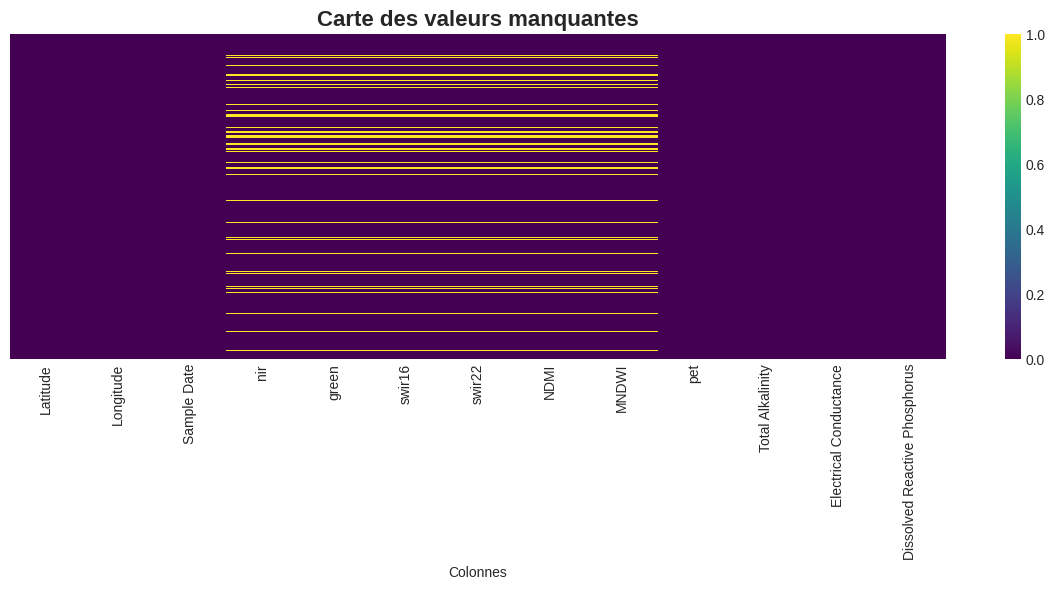

In [31]:
# Analyse des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': train_data.columns,
    'Valeurs manquantes': train_data.isnull().sum(),
    'Pourcentage (%)': (train_data.isnull().sum() / len(train_data)) * 100
})
missing_data = missing_data[missing_data['Valeurs manquantes'] > 0].sort_values(
    'Pourcentage (%)', ascending=False
)

print("\n" + "=" * 80)
print(" VALEURS MANQUANTES")
print("=" * 80)
if len(missing_data) == 0:
    print(" Aucune valeur manquante détectée!")
else:
    print(missing_data.to_string(index=False))

# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
sns.heatmap(train_data.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Carte des valeurs manquantes', fontsize=16, fontweight='bold')
plt.xlabel('Colonnes')
plt.tight_layout()
plt.show()

### 3.3 Distribution des variables cibles

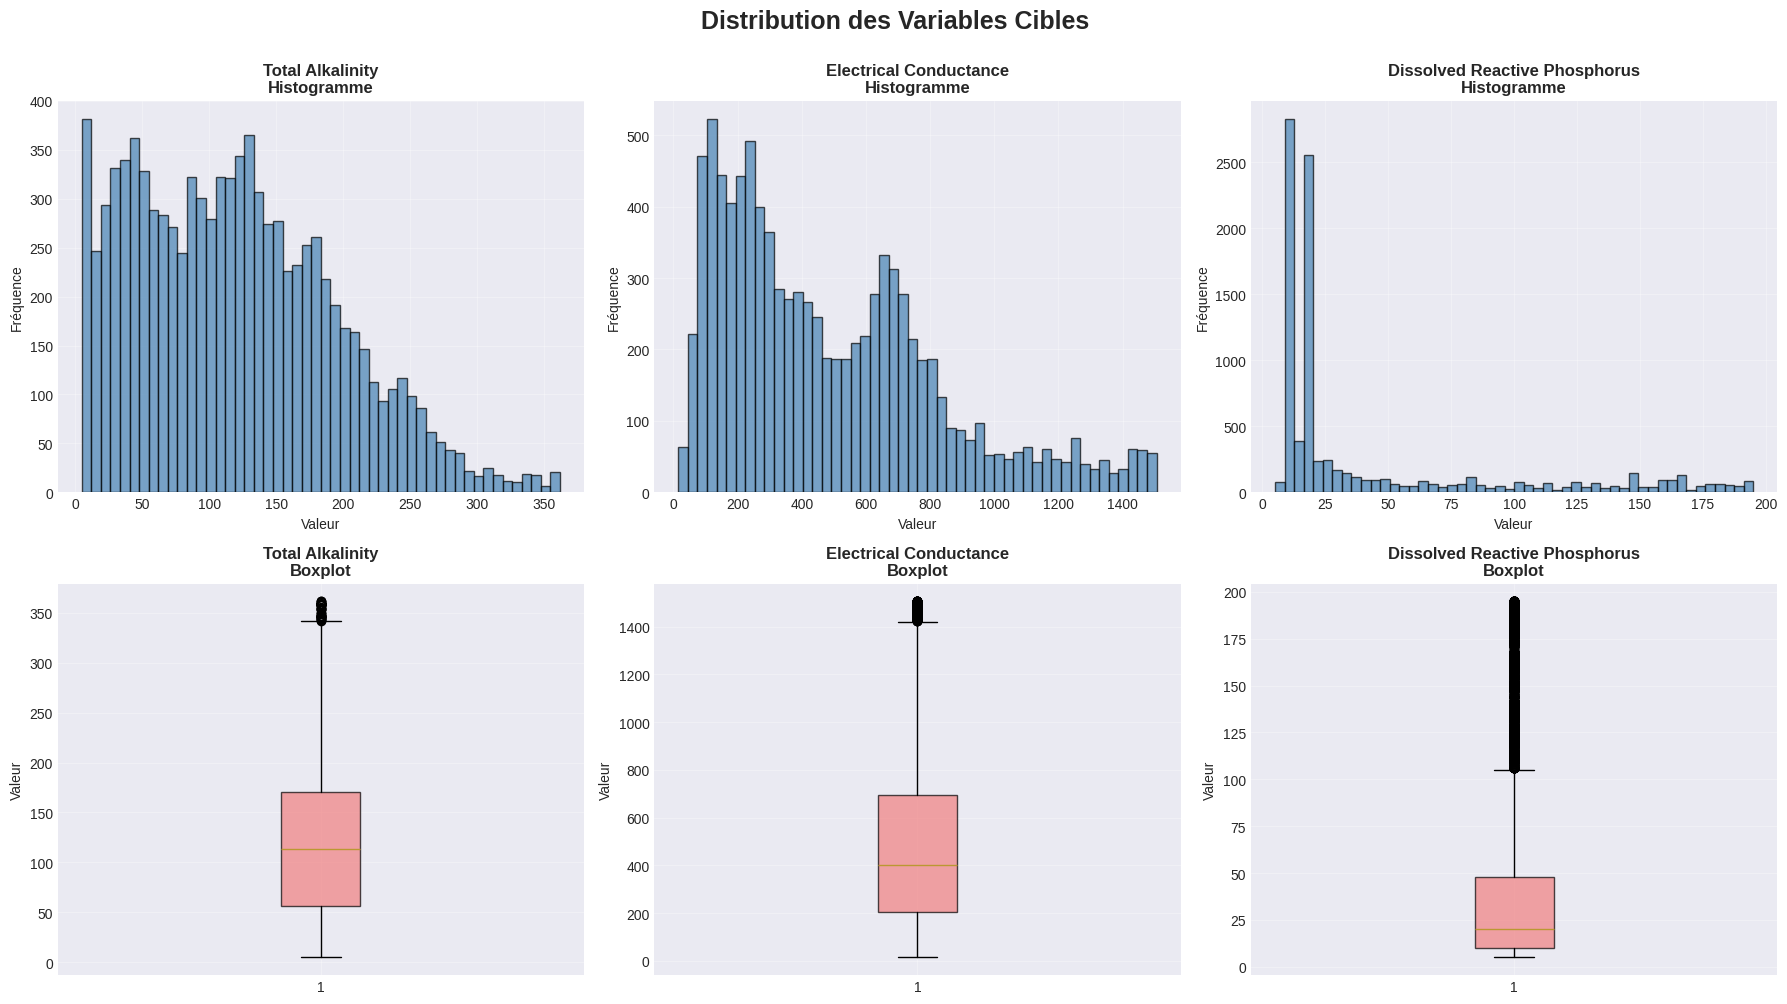


 STATISTIQUES DES VARIABLES CIBLES

Total Alkalinity:
  - Min: 4.80
  - Max: 361.68
  - Moyenne: 119.11
  - Médiane: 113.30
  - Écart-type: 74.69
  - Coefficient de variation: 62.71%

Electrical Conductance:
  - Min: 15.12
  - Max: 1506.00
  - Moyenne: 485.00
  - Médiane: 402.00
  - Écart-type: 341.94
  - Coefficient de variation: 70.50%

Dissolved Reactive Phosphorus:
  - Min: 5.00
  - Max: 195.00
  - Moyenne: 43.53
  - Médiane: 20.00
  - Écart-type: 50.98
  - Coefficient de variation: 117.13%


In [32]:
# Variables cibles
target_cols = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Création des sous-graphiques
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des Variables Cibles', fontsize=18, fontweight='bold', y=1.00)

for idx, target in enumerate(target_cols):
    # Histogramme
    axes[0, idx].hist(train_data[target].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{target}\nHistogramme', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Valeur')
    axes[0, idx].set_ylabel('Fréquence')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1, idx].boxplot(train_data[target].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[1, idx].set_title(f'{target}\nBoxplot', fontsize=12, fontweight='bold')
    axes[1, idx].set_ylabel('Valeur')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques sur les cibles
print("\n" + "=" * 80)
print(" STATISTIQUES DES VARIABLES CIBLES")
print("=" * 80)
for target in target_cols:
    data = train_data[target].dropna()
    print(f"\n{target}:")
    print(f"  - Min: {data.min():.2f}")
    print(f"  - Max: {data.max():.2f}")
    print(f"  - Moyenne: {data.mean():.2f}")
    print(f"  - Médiane: {data.median():.2f}")
    print(f"  - Écart-type: {data.std():.2f}")
    print(f"  - Coefficient de variation: {(data.std() / data.mean() * 100):.2f}%")

### 3.4 Distribution des features

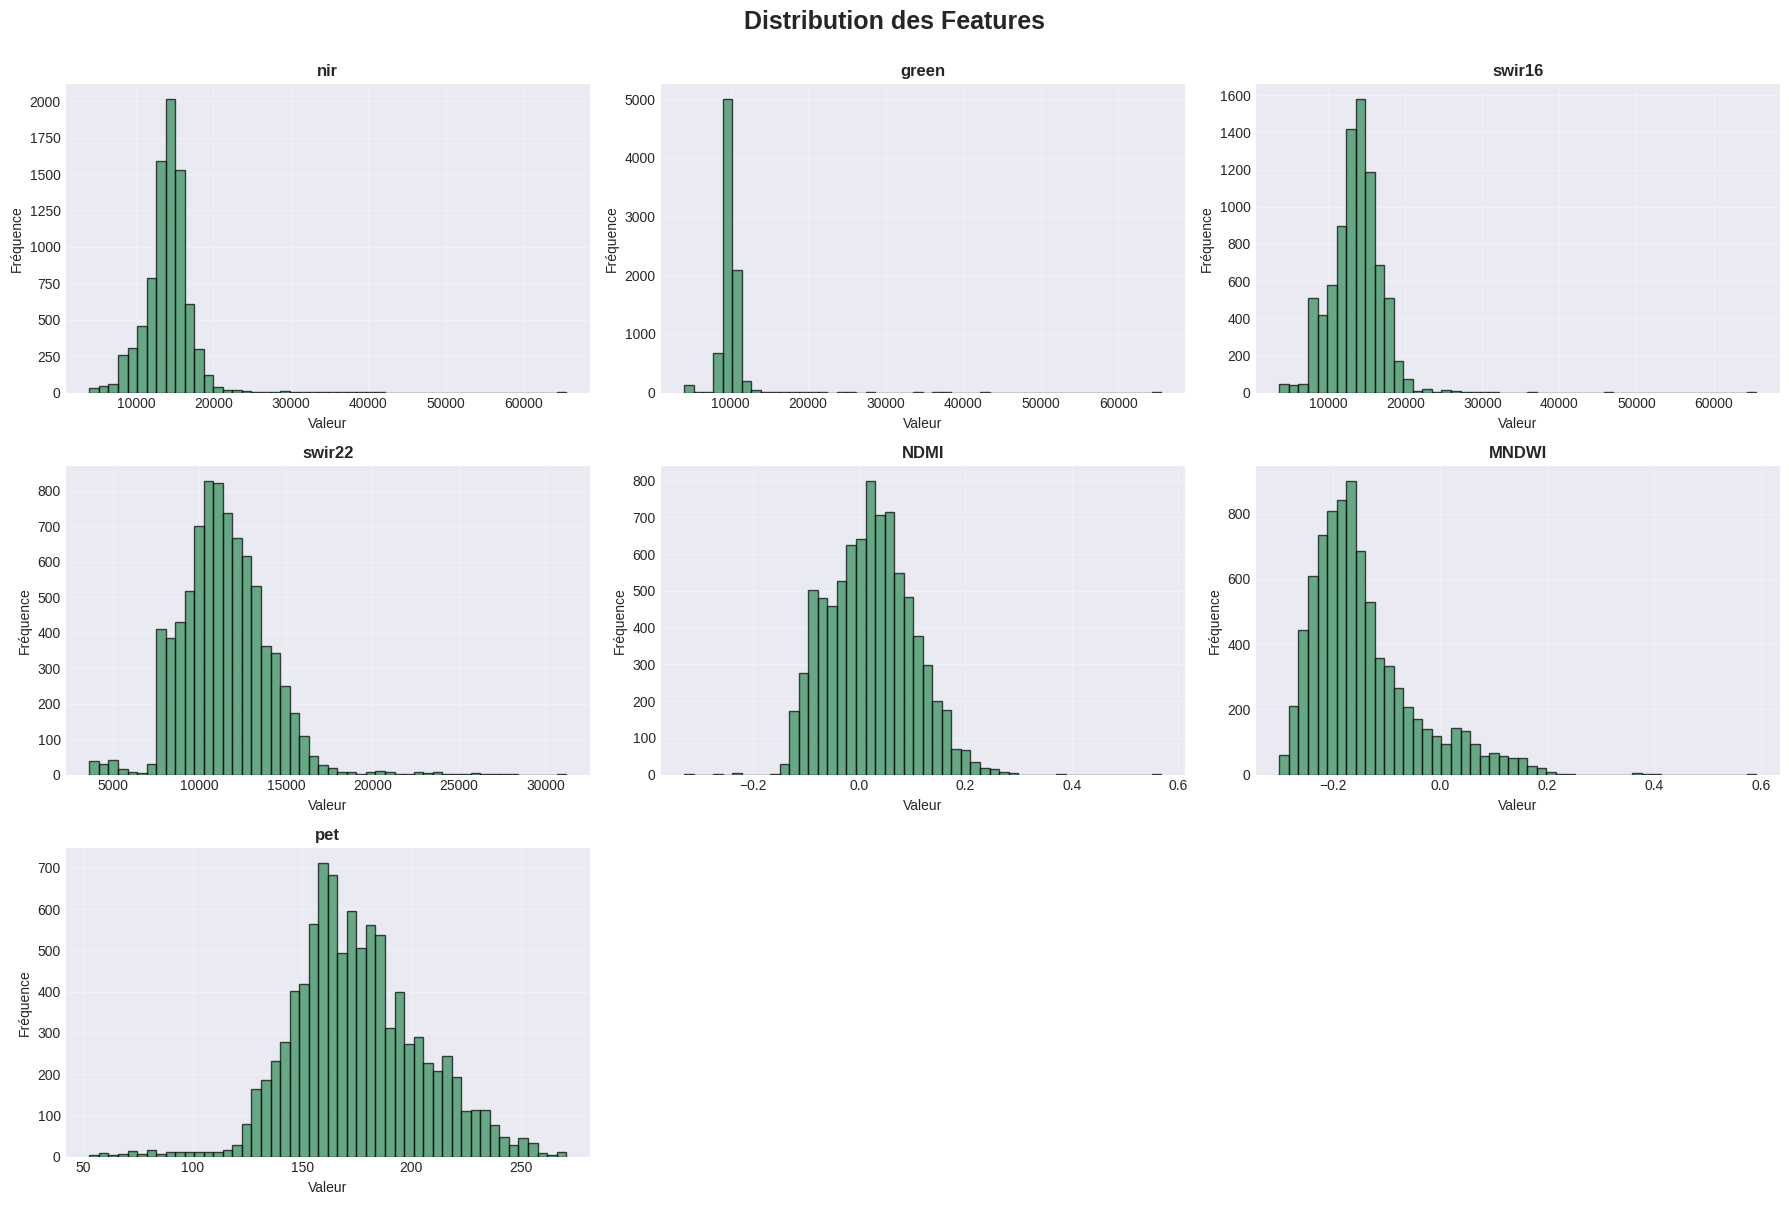

In [33]:
# Features numériques (hors coordonnées et date)
feature_cols = ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'pet']

# Visualisation des distributions
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Distribution des Features', fontsize=18, fontweight='bold', y=1.00)
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    axes[idx].hist(train_data[feature].dropna(), bins=50, color='seagreen', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

# Supprimer les axes vides
for idx in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

### 3.5 Matrice de corrélation

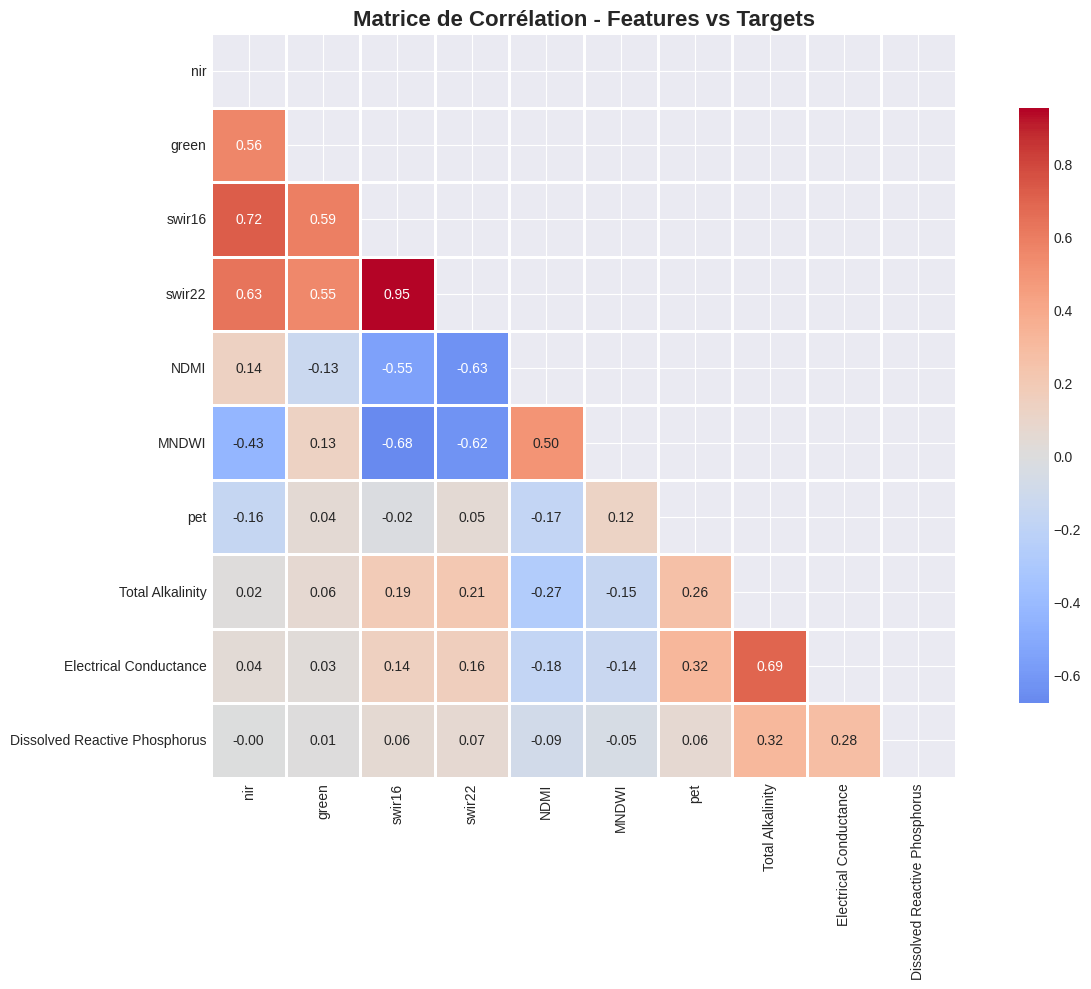


🔗 CORRÉLATIONS FEATURES ↔ TARGETS

Total Alkalinity:
Total Alkalinity    1.000000
pet                 0.263515
swir22              0.211446
swir16              0.191913
green               0.061622
nir                 0.015579
MNDWI              -0.154614

Electrical Conductance:
Electrical Conductance    1.000000
pet                       0.322811
swir22                    0.159797
swir16                    0.144659
nir                       0.037289
green                     0.028293
MNDWI                    -0.141569

Dissolved Reactive Phosphorus:
Dissolved Reactive Phosphorus    1.000000
swir22                           0.065900
pet                              0.062566
swir16                           0.059861
green                            0.008321
nir                             -0.004762
MNDWI                           -0.048319


In [34]:
# Sélection des colonnes numériques pour la corrélation
numeric_cols = feature_cols + target_cols
correlation_data = train_data[numeric_cols].corr()

# Visualisation de la matrice de corrélation
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_data, dtype=bool))
sns.heatmap(
    correlation_data, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matrice de Corrélation - Features vs Targets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélations avec les targets
print("\n" + "=" * 80)
print("🔗 CORRÉLATIONS FEATURES ↔ TARGETS")
print("=" * 80)
for target in target_cols:
    print(f"\n{target}:")
    corr = train_data[feature_cols + [target]].corr()[target].sort_values(ascending=False)
    print(corr[:-1].to_string())

### 3.6 Analyse temporelle

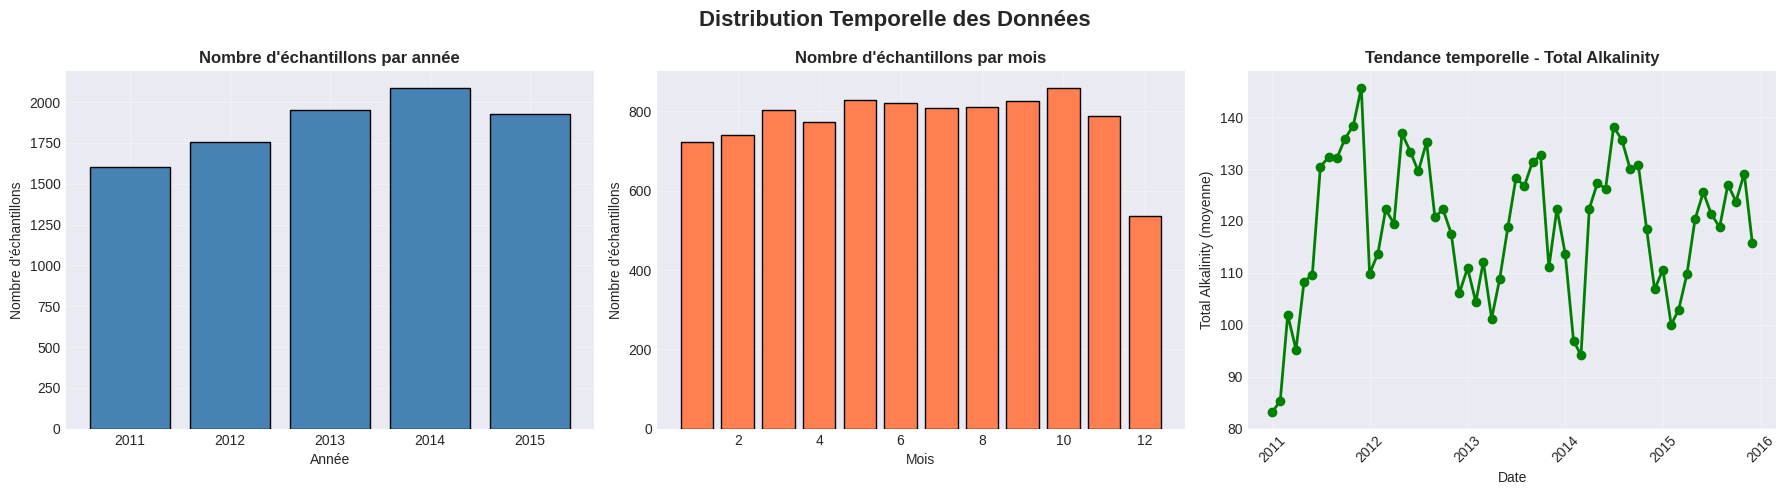

In [35]:
# Conversion de la colonne date
train_data['Date_parsed'] = pd.to_datetime(train_data['Sample Date'], format='%d-%m-%Y')
train_data['Year'] = train_data['Date_parsed'].dt.year
train_data['Month'] = train_data['Date_parsed'].dt.month
train_data['Day_of_year'] = train_data['Date_parsed'].dt.dayofyear

# Distribution temporelle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Temporelle des Données', fontsize=16, fontweight='bold')

# Par année
year_counts = train_data['Year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Nombre d\'échantillons par année', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].grid(True, alpha=0.3)

# Par mois
month_counts = train_data['Month'].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Nombre d\'échantillons par mois', fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre d\'échantillons')
axes[1].grid(True, alpha=0.3)

# Tendance temporelle d'une cible (exemple: Total Alkalinity)
monthly_avg = train_data.groupby(['Year', 'Month'])['Total Alkalinity'].mean().reset_index()
monthly_avg['Date'] = pd.to_datetime(monthly_avg[['Year', 'Month']].assign(DAY=1))
axes[2].plot(monthly_avg['Date'], monthly_avg['Total Alkalinity'], marker='o', color='green', linewidth=2)
axes[2].set_title('Tendance temporelle - Total Alkalinity', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Total Alkalinity (moyenne)')
axes[2].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.7 Analyse géospatiale

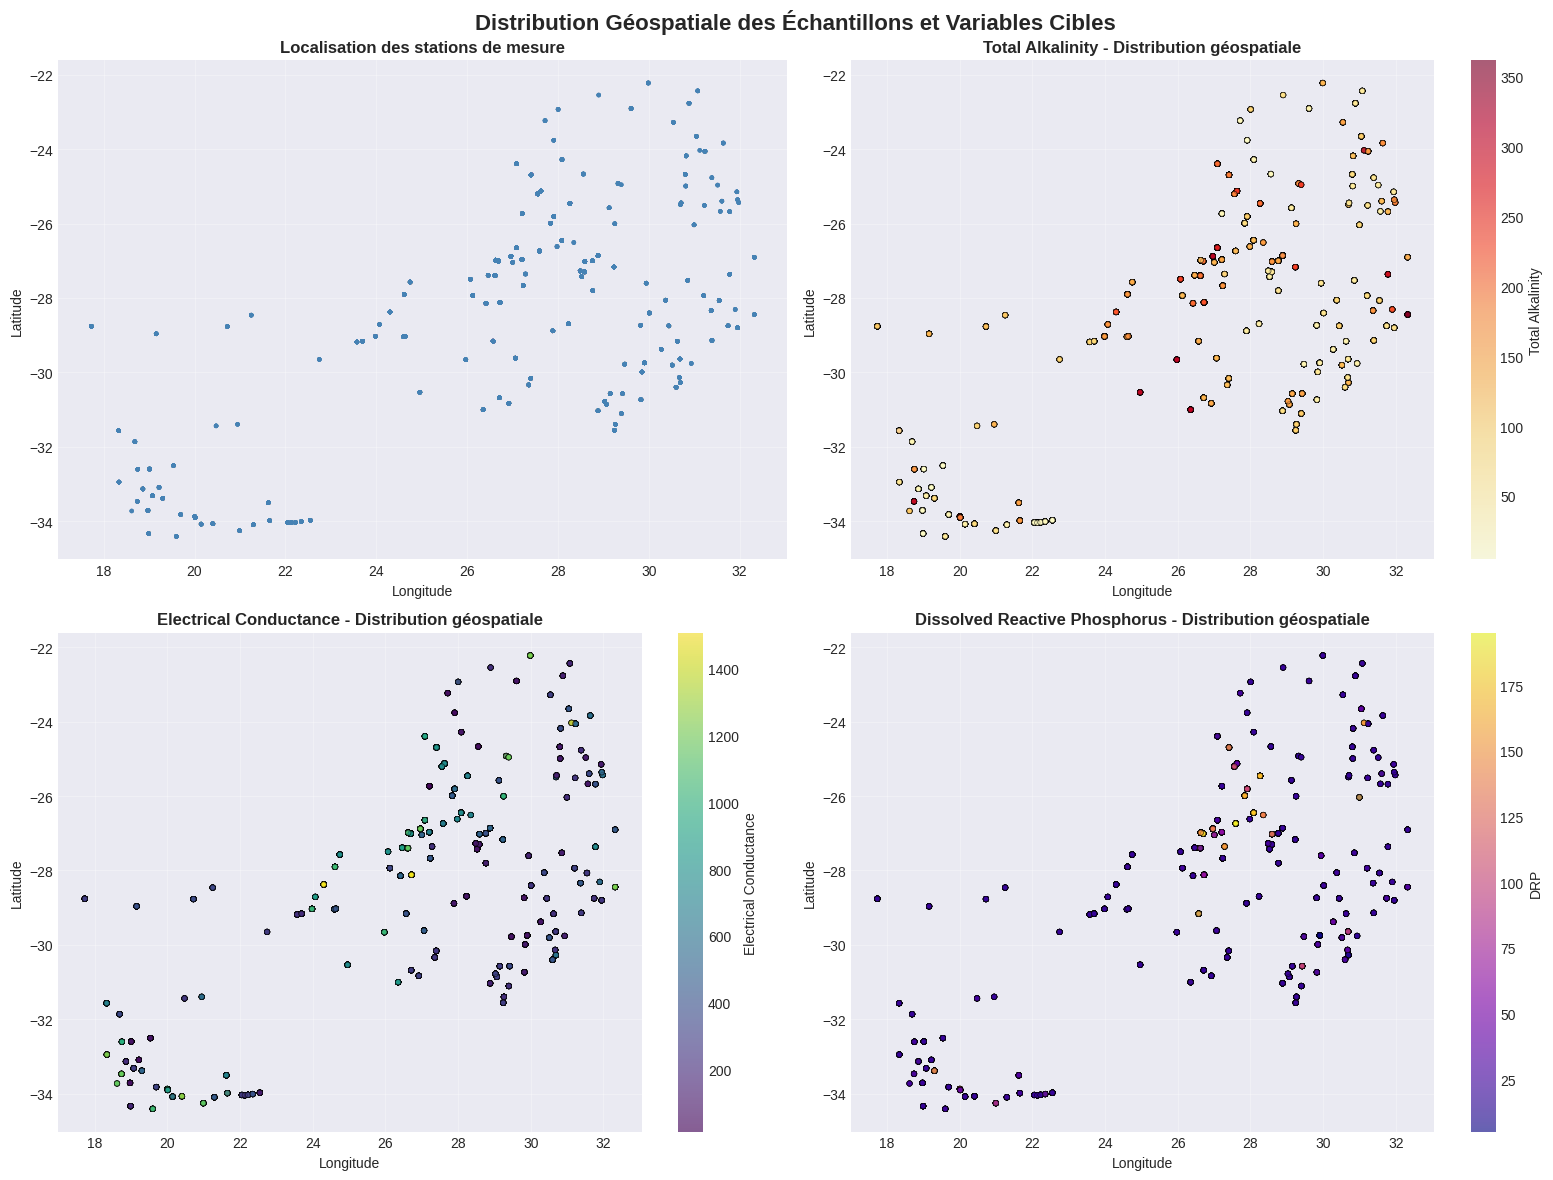

In [36]:
# Visualisation géospatiale des échantillons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Géospatiale des Échantillons et Variables Cibles', 
             fontsize=16, fontweight='bold')

# Distribution géographique simple
axes[0, 0].scatter(train_data['Longitude'], train_data['Latitude'], 
                   c='steelblue', alpha=0.5, s=10, edgecolors='none')
axes[0, 0].set_title('Localisation des stations de mesure', fontweight='bold')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].grid(True, alpha=0.3)

# Carte thermique - Total Alkalinity
scatter1 = axes[0, 1].scatter(train_data['Longitude'], train_data['Latitude'], 
                              c=train_data['Total Alkalinity'], 
                              cmap='YlOrRd', alpha=0.6, s=15, edgecolors='black', linewidths=0.5)
axes[0, 1].set_title('Total Alkalinity - Distribution géospatiale', fontweight='bold')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
plt.colorbar(scatter1, ax=axes[0, 1], label='Total Alkalinity')
axes[0, 1].grid(True, alpha=0.3)

# Carte thermique - Electrical Conductance
scatter2 = axes[1, 0].scatter(train_data['Longitude'], train_data['Latitude'], 
                              c=train_data['Electrical Conductance'], 
                              cmap='viridis', alpha=0.6, s=15, edgecolors='black', linewidths=0.5)
axes[1, 0].set_title('Electrical Conductance - Distribution géospatiale', fontweight='bold')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
plt.colorbar(scatter2, ax=axes[1, 0], label='Electrical Conductance')
axes[1, 0].grid(True, alpha=0.3)

# Carte thermique - Dissolved Reactive Phosphorus
scatter3 = axes[1, 1].scatter(train_data['Longitude'], train_data['Latitude'], 
                              c=train_data['Dissolved Reactive Phosphorus'], 
                              cmap='plasma', alpha=0.6, s=15, edgecolors='black', linewidths=0.5)
axes[1, 1].set_title('Dissolved Reactive Phosphorus - Distribution géospatiale', fontweight='bold')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
plt.colorbar(scatter3, ax=axes[1, 1], label='DRP')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Nettoyage & Preprocessing des données 🧹 {#section4}

### 4.1 Gestion des valeurs manquantes

In [37]:
# Vérification détaillée des valeurs manquantes dans le train
print("=" * 80)
print(" GESTION DES VALEURS MANQUANTES")
print("=" * 80)

missing_train = train_data.isnull().sum()
print(f"\nValeurs manquantes dans le train set:")
print(missing_train[missing_train > 0])

# Stratégie: Suppression des lignes avec valeurs manquantes (si peu nombreuses)
# Ou imputation (médiane/moyenne) si trop nombreuses
train_data_clean = train_data.dropna().copy()
print(f"\n Lignes supprimées: {len(train_data) - len(train_data_clean)}")
print(f" Données restantes: {len(train_data_clean)} lignes")

# Vérification des valeurs manquantes dans validation
missing_val = val_features.isnull().sum()
print(f"\nValeurs manquantes dans le validation set:")
print(missing_val[missing_val > 0])

# Si nécessaire, imputer les valeurs manquantes dans validation
if val_features.isnull().sum().sum() > 0:
    print("\n Imputation des valeurs manquantes dans le validation set...")
    for col in val_features.columns:
        if val_features[col].isnull().sum() > 0:
            if val_features[col].dtype in ['float64', 'int64']:
                val_features[col].fillna(val_features[col].median(), inplace=True)
    print(" Imputation terminée!")

 GESTION DES VALEURS MANQUANTES

Valeurs manquantes dans le train set:
nir       1085
green     1085
swir16    1085
swir22    1085
NDMI      1085
MNDWI     1085
dtype: int64

 Lignes supprimées: 1085
 Données restantes: 8234 lignes

Valeurs manquantes dans le validation set:
nir       19
green     19
swir16    19
swir22    19
NDMI      19
MNDWI     19
dtype: int64

 Imputation des valeurs manquantes dans le validation set...
 Imputation terminée!


### 4.2 Détection et gestion des outliers


 DÉTECTION DES OUTLIERS (Méthode IQR)

Total Alkalinity:
  - Outliers détectés: 33 (0.40%)
  - Borne inférieure: -116.85
  - Borne supérieure: 343.22

Electrical Conductance:
  - Outliers détectés: 156 (1.89%)
  - Borne inférieure: -526.50
  - Borne supérieure: 1426.30

Dissolved Reactive Phosphorus:
  - Outliers détectés: 1241 (15.07%)
  - Borne inférieure: -48.12
  - Borne supérieure: 106.88


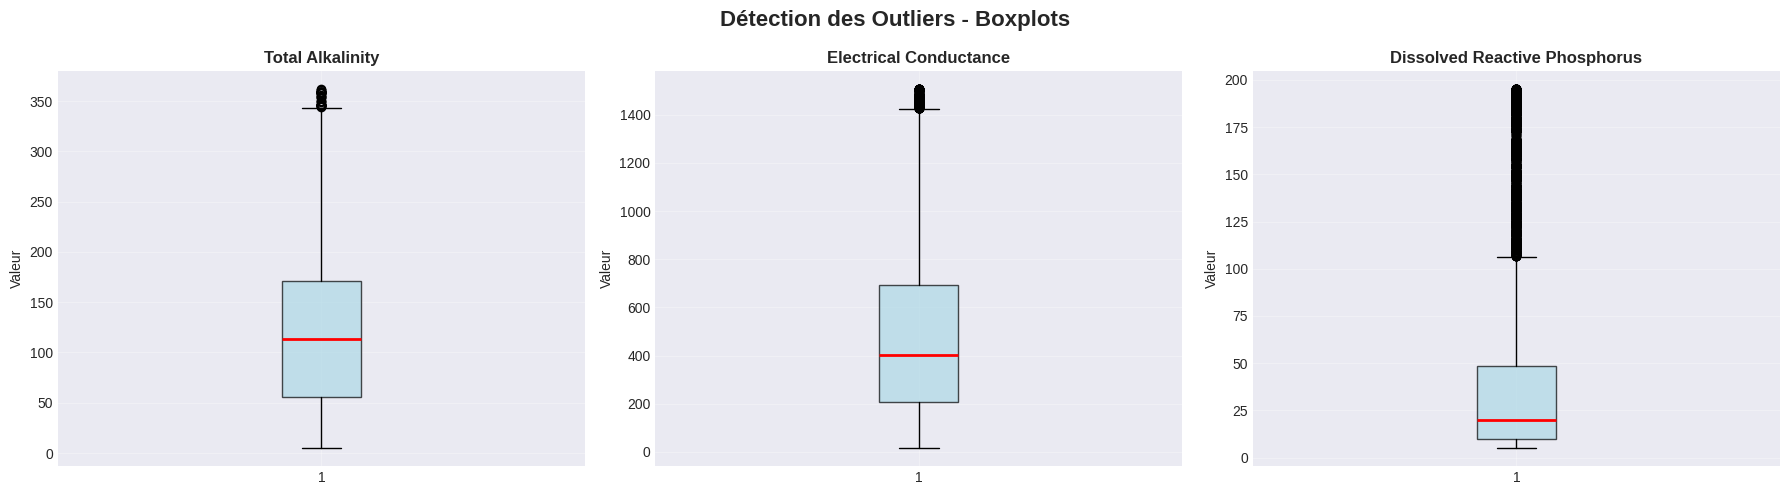


 Les outliers sont conservés (peuvent être des valeurs réelles importantes)
   → Utilisation de RobustScaler pour gérer leur impact


In [38]:
# Fonction pour détecter les outliers avec la méthode IQR
def detect_outliers_iqr(data, column, threshold=1.5):
    """
    Détecte les outliers avec la méthode IQR (Interquartile Range)
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyse des outliers pour chaque variable cible
print("\n" + "=" * 80)
print(" DÉTECTION DES OUTLIERS (Méthode IQR)")
print("=" * 80)

outliers_info = {}
for target in target_cols:
    outliers, lower, upper = detect_outliers_iqr(train_data_clean, target)
    outliers_info[target] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(train_data_clean)) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }
    print(f"\n{target}:")
    print(f"  - Outliers détectés: {len(outliers)} ({(len(outliers) / len(train_data_clean)) * 100:.2f}%)")
    print(f"  - Borne inférieure: {lower:.2f}")
    print(f"  - Borne supérieure: {upper:.2f}")

# Visualisation des outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Détection des Outliers - Boxplots', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_cols):
    axes[idx].boxplot(train_data_clean[target], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(target, fontweight='bold')
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Décision: Garder les outliers car ils peuvent représenter des vraies variations
# Pour un meilleur modèle robuste, on utilisera RobustScaler
print("\n Les outliers sont conservés (peuvent être des valeurs réelles importantes)")
print("   → Utilisation de RobustScaler pour gérer leur impact")

### 4.3 Vérification des duplicatas

In [39]:
# Vérification des doublons
duplicates = train_data_clean.duplicated().sum()
print("\n" + "=" * 80)
print(" VÉRIFICATION DES DUPLICATAS")
print("=" * 80)
print(f"\nNombre de lignes dupliquées: {duplicates}")

if duplicates > 0:
    train_data_clean = train_data_clean.drop_duplicates()
    print(f" {duplicates} lignes dupliquées supprimées")
else:
    print(" Aucun duplicata détecté")

print(f"\n Dataset final après nettoyage: {train_data_clean.shape}")


 VÉRIFICATION DES DUPLICATAS

Nombre de lignes dupliquées: 0
 Aucun duplicata détecté

 Dataset final après nettoyage: (8234, 17)


---
## 5. Feature Engineering 🔧 {#section5}

### 5.1 Création de nouvelles features

In [40]:
def create_features(df):
    """
    Crée de nouvelles features pertinentes pour la prédiction de qualité de l'eau
    """
    df = df.copy()
    
    # === Features temporelles ===
    df['Date_parsed'] = pd.to_datetime(df['Sample Date'], format='%d-%m-%Y')
    df['Year'] = df['Date_parsed'].dt.year
    df['Month'] = df['Date_parsed'].dt.month
    df['Day'] = df['Date_parsed'].dt.day
    df['Day_of_year'] = df['Date_parsed'].dt.dayofyear
    df['Quarter'] = df['Date_parsed'].dt.quarter
    df['Week_of_year'] = df['Date_parsed'].dt.isocalendar().week.astype(int)
    
    # Season (saisons de l'hémisphère sud)
    df['Season'] = df['Month'].apply(lambda x: 
        1 if x in [12, 1, 2] else  # Été
        2 if x in [3, 4, 5] else   # Automne
        3 if x in [6, 7, 8] else   # Hiver
        4)                          # Printemps
    
    # === Features spectrales dérivées ===
    # Normalized Difference Vegetation Index
    df['NDVI'] = (df['nir'] - df['green']) / (df['nir'] + df['green'] + 1e-8)
    
    # Enhanced Vegetation Index
    df['EVI'] = 2.5 * ((df['nir'] - df['green']) / 
                       (df['nir'] + 6 * df['green'] - 7.5 * df['swir22'] + 1 + 1e-8))
    
    # Normalized Difference Turbidity Index
    df['NDTI'] = (df['green'] - df['swir16']) / (df['green'] + df['swir16'] + 1e-8)
    
    # Water Index
    df['WI'] = (df['green'] + df['nir']) / (df['swir16'] + df['swir22'] + 1e-8)
    
    # Ratios spectraux
    df['nir_green_ratio'] = df['nir'] / (df['green'] + 1e-8)
    df['swir_ratio'] = df['swir22'] / (df['swir16'] + 1e-8)
    df['green_nir_ratio'] = df['green'] / (df['nir'] + 1e-8)
    
    # === Features d'interaction ===
    df['NDMI_pet'] = df['NDMI'] * df['pet']
    df['MNDWI_pet'] = df['MNDWI'] * df['pet']
    df['nir_pet'] = df['nir'] * df['pet']
    
    # === Features géospatiales ===
    # Distance from a reference point (approximate center of South Africa)
    ref_lat, ref_lon = -29.0, 24.0
    df['distance_from_center'] = np.sqrt(
        (df['Latitude'] - ref_lat)**2 + (df['Longitude'] - ref_lon)**2
    )
    
    # Interaction Lat-Long
    df['lat_lon_interaction'] = df['Latitude'] * df['Longitude']
    
    # === Features statistiques (rolling/aggregations si pertinent) ===
    # Polynomiales
    df['pet_squared'] = df['pet'] ** 2
    df['NDMI_squared'] = df['NDMI'] ** 2
    df['MNDWI_squared'] = df['MNDWI'] ** 2
    
    return df

# Application du feature engineering
print("=" * 80)
print(" FEATURE ENGINEERING")
print("=" * 80)
print("\n Création des nouvelles features...")

train_data_fe = create_features(train_data_clean)
val_features_fe = create_features(val_features)

# Nouvelles features créées
original_features = set(train_data_clean.columns)
new_features = set(train_data_fe.columns) - original_features
print(f"\n {len(new_features)} nouvelles features créées:")
for i, feat in enumerate(sorted(new_features), 1):
    print(f"   {i}. {feat}")

print(f"\n Shape après feature engineering:")
print(f"   - Train: {train_data_fe.shape}")
print(f"   - Validation: {val_features_fe.shape}")

 FEATURE ENGINEERING

 Création des nouvelles features...

 19 nouvelles features créées:
   1. Day
   2. EVI
   3. MNDWI_pet
   4. MNDWI_squared
   5. NDMI_pet
   6. NDMI_squared
   7. NDTI
   8. NDVI
   9. Quarter
   10. Season
   11. WI
   12. Week_of_year
   13. distance_from_center
   14. green_nir_ratio
   15. lat_lon_interaction
   16. nir_green_ratio
   17. nir_pet
   18. pet_squared
   19. swir_ratio

 Shape après feature engineering:
   - Train: (8234, 36)
   - Validation: (200, 33)


### 5.2 Sélection des features pour le modèle

In [41]:
# Définition des colonnes à exclure
exclude_cols = ['Sample Date', 'Date_parsed', 'Total Alkalinity', 
                'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# Features finales
feature_columns = [col for col in train_data_fe.columns if col not in exclude_cols]

print("\n" + "=" * 80)
print(" FEATURES FINALES POUR LA MODÉLISATION")
print("=" * 80)
print(f"\nNombre total de features: {len(feature_columns)}\n")

# Organisation par catégorie
categories = {
    'Géospatiales': ['Latitude', 'Longitude', 'distance_from_center', 'lat_lon_interaction'],
    'Temporelles': ['Year', 'Month', 'Day', 'Day_of_year', 'Quarter', 'Week_of_year', 'Season'],
    'Spectrales Landsat': ['nir', 'green', 'swir16', 'swir22'],
    'Indices Spectraux': ['NDMI', 'MNDWI', 'NDVI', 'EVI', 'NDTI', 'WI'],
    'Climatiques': ['pet'],
    'Ratios & Interactions': [col for col in feature_columns if 'ratio' in col.lower() or 
                              ('_' in col and any(x in col for x in ['nir', 'pet', 'NDMI', 'MNDWI']))],
    'Polynomiales': [col for col in feature_columns if 'squared' in col.lower()]
}

for category, features in categories.items():
    features_present = [f for f in features if f in feature_columns]
    if features_present:
        print(f"{category} ({len(features_present)}):")
        for feat in features_present:
            print(f"  • {feat}")
        print()


 FEATURES FINALES POUR LA MODÉLISATION

Nombre total de features: 31

Géospatiales (4):
  • Latitude
  • Longitude
  • distance_from_center
  • lat_lon_interaction

Temporelles (7):
  • Year
  • Month
  • Day
  • Day_of_year
  • Quarter
  • Week_of_year
  • Season

Spectrales Landsat (4):
  • nir
  • green
  • swir16
  • swir22

Indices Spectraux (6):
  • NDMI
  • MNDWI
  • NDVI
  • EVI
  • NDTI
  • WI

Climatiques (1):
  • pet

Ratios & Interactions (9):
  • nir_green_ratio
  • swir_ratio
  • green_nir_ratio
  • NDMI_pet
  • MNDWI_pet
  • nir_pet
  • pet_squared
  • NDMI_squared
  • MNDWI_squared

Polynomiales (3):
  • pet_squared
  • NDMI_squared
  • MNDWI_squared



---
## 6. Préparation des données pour l'entraînement  {#section6}

### 6.1 Séparation X et y

In [42]:
# Séparation features et targets
X = train_data_fe[feature_columns].copy()
y = train_data_fe[target_cols].copy()

# Features pour le test (validation)
X_test = val_features_fe[feature_columns].copy()

print("=" * 80)
print(" PRÉPARATION DES DONNÉES")
print("=" * 80)
print(f"\n X (features train): {X.shape}")
print(f" y (targets train): {y.shape}")
print(f" X_test (features validation): {X_test.shape}")

# Vérification finale des NaN
print(f"\n Vérification des valeurs manquantes:")
print(f"   - X: {X.isnull().sum().sum()} NaN")
print(f"   - y: {y.isnull().sum().sum()} NaN")
print(f"   - X_test: {X_test.isnull().sum().sum()} NaN")

# Aperçu
print(f"\n Aperçu des données:")
print(X.head())

 PRÉPARATION DES DONNÉES

 X (features train): (8234, 31)
 y (targets train): (8234, 3)
 X_test (features validation): (200, 31)

 Vérification des valeurs manquantes:
   - X: 0 NaN
   - y: 0 NaN
   - X_test: 0 NaN

 Aperçu des données:
    Latitude  Longitude      nir    green   swir16   swir22      NDMI  \
0 -28.760833  17.730278  11190.0  11426.0   7687.5   7645.0  0.185538   
1 -26.861111  28.884722  17658.5   9550.0  13746.5  10574.0  0.124566   
2 -26.450000  28.085833  15210.0  10720.0  17974.0  14201.0 -0.083293   
3 -27.671111  27.236944  14887.0  10943.0  13522.0  11403.0  0.048048   
4 -27.356667  27.286389  16828.5   9502.5  12665.5   9643.0  0.141147   

      MNDWI    pet  Year  Month  Day_of_year  Day  Quarter  Week_of_year  \
0  0.195595  174.2  2011      1            2    2        1            52   
1 -0.180134  124.1  2011      1            3    3        1             1   
2 -0.252805  127.5  2011      1            3    3        1             1   
3 -0.105416  129.7  

### 6.2 Split train/validation avec plusieurs stratégies

In [43]:
# Comme les données sont temporelles, on va tester 2 approches:
# 1. Split aléatoire classique (80/20)
# 2. Split temporel (pour éviter le data leakage temporel)

# === Approche 1: Split aléatoire ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("\n" + "=" * 80)
print(" SPLIT DES DONNÉES - Approche Aléatoire")
print("=" * 80)
print(f"\n X_train: {X_train.shape}")
print(f" X_val: {X_val.shape}")
print(f" y_train: {y_train.shape}")
print(f" y_val: {y_val.shape}")

# === Approche 2: Split temporel (on le préparera pour comparaison) ===
# On trie par date et on prend les 80% premiers pour train, 20% derniers pour val
train_data_fe_sorted = train_data_fe.sort_values('Date_parsed')
split_idx = int(len(train_data_fe_sorted) * 0.8)

X_train_temporal = train_data_fe_sorted[feature_columns].iloc[:split_idx]
X_val_temporal = train_data_fe_sorted[feature_columns].iloc[split_idx:]
y_train_temporal = train_data_fe_sorted[target_cols].iloc[:split_idx]
y_val_temporal = train_data_fe_sorted[target_cols].iloc[split_idx:]

print("\n" + "=" * 80)
print(" SPLIT DES DONNÉES - Approche Temporelle")
print("=" * 80)
print(f"\n X_train_temporal: {X_train_temporal.shape}")
print(f" X_val_temporal: {X_val_temporal.shape}")
print(f" y_train_temporal: {y_train_temporal.shape}")
print(f" y_val_temporal: {y_val_temporal.shape}")

print("\n Note: Nous utiliserons le split aléatoire pour le développement principal,")
print("   et le split temporel pour validation de robustesse.")


 SPLIT DES DONNÉES - Approche Aléatoire

 X_train: (6587, 31)
 X_val: (1647, 31)
 y_train: (6587, 3)
 y_val: (1647, 3)

 SPLIT DES DONNÉES - Approche Temporelle

 X_train_temporal: (6587, 31)
 X_val_temporal: (1647, 31)
 y_train_temporal: (6587, 3)
 y_val_temporal: (1647, 3)

 Note: Nous utiliserons le split aléatoire pour le développement principal,
   et le split temporel pour validation de robustesse.


### 6.3 Normalisation des données

In [44]:
# On va créer 2 scalers: StandardScaler et RobustScaler
# RobustScaler est plus robuste aux outliers

# StandardScaler
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train)
X_val_scaled = scaler_standard.transform(X_val)
X_test_scaled = scaler_standard.transform(X_test)

# RobustScaler (préférable avec outliers)
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_val_robust = scaler_robust.transform(X_val)
X_test_robust = scaler_robust.transform(X_test)

print("\n" + "=" * 80)
print("⚖️ NORMALISATION DES DONNÉES")
print("=" * 80)
print("\n 2 types de scalers créés:")
print("   1. StandardScaler (moyenne=0, écart-type=1)")
print("   2. RobustScaler (médiane=0, IQR=1) - Plus robuste aux outliers")
print("\n Données normalisées:")
print(f"   - X_train_scaled: {X_train_scaled.shape}")
print(f"   - X_val_scaled: {X_val_scaled.shape}")
print(f"   - X_test_scaled: {X_test_scaled.shape}")

# On utilisera RobustScaler par défaut
X_train_final = X_train_robust
X_val_final = X_val_robust
X_test_final = X_test_robust

print("\n Utilisation de RobustScaler pour la suite")


⚖️ NORMALISATION DES DONNÉES

 2 types de scalers créés:
   1. StandardScaler (moyenne=0, écart-type=1)
   2. RobustScaler (médiane=0, IQR=1) - Plus robuste aux outliers

 Données normalisées:
   - X_train_scaled: (6587, 31)
   - X_val_scaled: (1647, 31)
   - X_test_scaled: (200, 31)

 Utilisation de RobustScaler pour la suite


---
## 7. Modélisation - Modèles de Base  {#section7}

### 7.1 Définition des fonctions d'évaluation

In [45]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Évalue un modèle avec plusieurs métriques pour chaque cible
    """
    results = {}
    
    for idx, target in enumerate(target_cols):
        r2 = r2_score(y_true.iloc[:, idx], y_pred[:, idx])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, idx], y_pred[:, idx]))
        mae = mean_absolute_error(y_true.iloc[:, idx], y_pred[:, idx])
        
        results[target] = {
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        }
    
    # Moyenne des métriques
    avg_r2 = np.mean([results[t]['R²'] for t in target_cols])
    avg_rmse = np.mean([results[t]['RMSE'] for t in target_cols])
    avg_mae = np.mean([results[t]['MAE'] for t in target_cols])
    
    results['AVERAGE'] = {
        'R²': avg_r2,
        'RMSE': avg_rmse,
        'MAE': avg_mae
    }
    
    return results

def print_results(results, model_name="Model"):
    """
    Affiche les résultats de manière formatée
    """
    print(f"\n{'=' * 80}")
    print(f" RÉSULTATS - {model_name}")
    print(f"{'=' * 80}")
    
    for target in target_cols + ['AVERAGE']:
        print(f"\n{target}:")
        print(f"  • R²   = {results[target]['R²']:.4f}")
        print(f"  • RMSE = {results[target]['RMSE']:.2f}")
        print(f"  • MAE  = {results[target]['MAE']:.2f}")

print(" Fonctions d'évaluation définies!")

 Fonctions d'évaluation définies!


### 7.2 Random Forest Regressor

In [46]:
print("\n" + "=" * 80)
print(" ENTRAINEMENT - RANDOM FOREST")
print("=" * 80)

# Initialisation et entraînement
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
)

print("\n Entraînement en cours...")
rf_model.fit(X_train_final, y_train)
print(" Entraînement terminé!")

# Prédictions
y_train_pred_rf = rf_model.predict(X_train_final)
y_val_pred_rf = rf_model.predict(X_val_final)

# Évaluation
print("\n Performance sur TRAIN:")
rf_train_results = evaluate_model(y_train, y_train_pred_rf, "Random Forest - Train")
print_results(rf_train_results, "Random Forest - Train")

print("\n Performance sur VALIDATION:")
rf_val_results = evaluate_model(y_val, y_val_pred_rf, "Random Forest - Validation")
print_results(rf_val_results, "Random Forest - Validation")


 ENTRAINEMENT - RANDOM FOREST

 Entraînement en cours...
 Entraînement terminé!

 Performance sur TRAIN:

 RÉSULTATS - Random Forest - Train

Total Alkalinity:
  • R²   = 0.9398
  • RMSE = 18.43
  • MAE  = 12.32

Electrical Conductance:
  • R²   = 0.9468
  • RMSE = 79.10
  • MAE  = 48.97

Dissolved Reactive Phosphorus:
  • R²   = 0.8930
  • RMSE = 16.77
  • MAE  = 10.14

AVERAGE:
  • R²   = 0.9265
  • RMSE = 38.10
  • MAE  = 23.81

 Performance sur VALIDATION:

 RÉSULTATS - Random Forest - Validation

Total Alkalinity:
  • R²   = 0.8225
  • RMSE = 31.32
  • MAE  = 22.10

Electrical Conductance:
  • R²   = 0.8435
  • RMSE = 137.23
  • MAE  = 88.13

Dissolved Reactive Phosphorus:
  • R²   = 0.6774
  • RMSE = 28.89
  • MAE  = 17.96

AVERAGE:
  • R²   = 0.7811
  • RMSE = 65.81
  • MAE  = 42.73


In [47]:
# ANALYSE OVERFITTING - Random Forest
print("\n" + "=" * 80)
print("ANALYSE D'OVERFITTING - RANDOM FOREST")
print("=" * 80)

print("\nCOMPARAISON TRAIN vs VALIDATION:")
print("-" * 80)

for target in target_cols:
    train_r2 = rf_train_results[target]['R²']
    val_r2 = rf_val_results[target]['R²']
    gap = train_r2 - val_r2
    
    print(f"\n{target}:")
    print(f"  Train R²      : {train_r2:.4f}")
    print(f"  Validation R² : {val_r2:.4f}")
    print(f"  Différence    : {gap:.4f}", end="")
    
    if gap > 0.15:
        print(" [ALERTE: Overfitting important]")
    elif gap > 0.10:
        print(" [ATTENTION: Overfitting modéré]")
    elif gap > 0.05:
        print(" [Léger overfitting]")
    else:
        print(" [Bon équilibre]")

# Moyenne
avg_train_r2 = rf_train_results['AVERAGE']['R²']
avg_val_r2 = rf_val_results['AVERAGE']['R²']
avg_gap = avg_train_r2 - avg_val_r2

print(f"\nMOYENNE GLOBALE:")
print(f"  Train R²      : {avg_train_r2:.4f}")
print(f"  Validation R² : {avg_val_r2:.4f}")
print(f"  Différence    : {avg_gap:.4f}", end="")

if avg_gap > 0.15:
    print(" [ALERTE: Overfitting important]")
elif avg_gap > 0.10:
    print(" [ATTENTION: Overfitting modéré]")
elif avg_gap > 0.05:
    print(" [Léger overfitting]")
else:
    print(" [Bon équilibre]")


ANALYSE D'OVERFITTING - RANDOM FOREST

COMPARAISON TRAIN vs VALIDATION:
--------------------------------------------------------------------------------

Total Alkalinity:
  Train R²      : 0.9398
  Validation R² : 0.8225
  Différence    : 0.1173 [ATTENTION: Overfitting modéré]

Electrical Conductance:
  Train R²      : 0.9468
  Validation R² : 0.8435
  Différence    : 0.1033 [ATTENTION: Overfitting modéré]

Dissolved Reactive Phosphorus:
  Train R²      : 0.8930
  Validation R² : 0.6774
  Différence    : 0.2156 [ALERTE: Overfitting important]

MOYENNE GLOBALE:
  Train R²      : 0.9265
  Validation R² : 0.7811
  Différence    : 0.1454 [ATTENTION: Overfitting modéré]


### 7.3 XGBoost Regressor

In [48]:
print("\n" + "=" * 80)
print(" ENTRAINEMENT - XGBOOST")
print("=" * 80)

# Initialisation et entraînement avec early stopping
xgb_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
)

print("\n Entraînement en cours avec early stopping...")
# Pour l'early stopping, on doit entraîner chaque target séparément
xgb_models = []
for idx, target in enumerate(target_cols):
    print(f"   → Entraînement pour {target}...")
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_train_final, y_train.iloc[:, idx],
        eval_set=[(X_val_final, y_val.iloc[:, idx])],
        verbose=False
    )
    xgb_models.append(model)

print(" Entraînement terminé!")

# Prédictions
y_train_pred_xgb = np.column_stack([model.predict(X_train_final) for model in xgb_models])
y_val_pred_xgb = np.column_stack([model.predict(X_val_final) for model in xgb_models])

# Évaluation
print("\n Performance sur TRAIN:")
xgb_train_results = evaluate_model(y_train, y_train_pred_xgb, "XGBoost - Train")
print_results(xgb_train_results, "XGBoost - Train")

print("\n Performance sur VALIDATION:")
xgb_val_results = evaluate_model(y_val, y_val_pred_xgb, "XGBoost - Validation")
print_results(xgb_val_results, "XGBoost - Validation")


 ENTRAINEMENT - XGBOOST

 Entraînement en cours avec early stopping...
   → Entraînement pour Total Alkalinity...
   → Entraînement pour Electrical Conductance...
   → Entraînement pour Dissolved Reactive Phosphorus...
 Entraînement terminé!

 Performance sur TRAIN:

 RÉSULTATS - XGBoost - Train

Total Alkalinity:
  • R²   = 0.9920
  • RMSE = 6.70
  • MAE  = 4.43

Electrical Conductance:
  • R²   = 0.9947
  • RMSE = 25.03
  • MAE  = 16.43

Dissolved Reactive Phosphorus:
  • R²   = 0.9882
  • RMSE = 5.58
  • MAE  = 3.32

AVERAGE:
  • R²   = 0.9916
  • RMSE = 12.44
  • MAE  = 8.06

 Performance sur VALIDATION:

 RÉSULTATS - XGBoost - Validation

Total Alkalinity:
  • R²   = 0.8586
  • RMSE = 27.95
  • MAE  = 18.76

Electrical Conductance:
  • R²   = 0.8854
  • RMSE = 117.42
  • MAE  = 71.25

Dissolved Reactive Phosphorus:
  • R²   = 0.6927
  • RMSE = 28.20
  • MAE  = 16.37

AVERAGE:
  • R²   = 0.8122
  • RMSE = 57.86
  • MAE  = 35.46


In [49]:
# ANALYSE OVERFITTING - XGBoost
print("\n" + "=" * 80)
print("ANALYSE D'OVERFITTING - XGBOOST")
print("=" * 80)

print("\nCOMPARAISON TRAIN vs VALIDATION:")
print("-" * 80)

for target in target_cols:
    train_r2 = xgb_train_results[target]['R²']
    val_r2 = xgb_val_results[target]['R²']
    gap = train_r2 - val_r2
    
    print(f"\n{target}:")
    print(f"  Train R²      : {train_r2:.4f}")
    print(f"  Validation R² : {val_r2:.4f}")
    print(f"  Différence    : {gap:.4f}", end="")
    
    if gap > 0.15:
        print(" [ALERTE: Overfitting important]")
    elif gap > 0.10:
        print(" [ATTENTION: Overfitting modéré]")
    elif gap > 0.05:
        print(" [Léger overfitting]")
    else:
        print(" [Bon équilibre]")

# Moyenne
avg_train_r2 = xgb_train_results['AVERAGE']['R²']
avg_val_r2 = xgb_val_results['AVERAGE']['R²']
avg_gap = avg_train_r2 - avg_val_r2

print(f"\nMOYENNE GLOBALE:")
print(f"  Train R²      : {avg_train_r2:.4f}")
print(f"  Validation R² : {avg_val_r2:.4f}")
print(f"  Différence    : {avg_gap:.4f}", end="")

if avg_gap > 0.15:
    print(" [ALERTE: Overfitting important]")
elif avg_gap > 0.10:
    print(" [ATTENTION: Overfitting modéré]")
elif avg_gap > 0.05:
    print(" [Léger overfitting]")
else:
    print(" [Bon équilibre]")


ANALYSE D'OVERFITTING - XGBOOST

COMPARAISON TRAIN vs VALIDATION:
--------------------------------------------------------------------------------

Total Alkalinity:
  Train R²      : 0.9920
  Validation R² : 0.8586
  Différence    : 0.1334 [ATTENTION: Overfitting modéré]

Electrical Conductance:
  Train R²      : 0.9947
  Validation R² : 0.8854
  Différence    : 0.1093 [ATTENTION: Overfitting modéré]

Dissolved Reactive Phosphorus:
  Train R²      : 0.9882
  Validation R² : 0.6927
  Différence    : 0.2955 [ALERTE: Overfitting important]

MOYENNE GLOBALE:
  Train R²      : 0.9916
  Validation R² : 0.8122
  Différence    : 0.1794 [ALERTE: Overfitting important]


### 7.4 LightGBM Regressor

In [50]:
print("\n" + "=" * 80)
print(" ENTRAINEMENT - LIGHTGBM")
print("=" * 80)

# Initialisation et entraînement
lgb_models = []
for idx, target in enumerate(target_cols):
    print(f"\n Entraînement pour {target}...")
    model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_train_final, y_train.iloc[:, idx],
        eval_set=[(X_val_final, y_val.iloc[:, idx])],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    lgb_models.append(model)

print("\n Entraînement terminé!")

# Prédictions
y_train_pred_lgb = np.column_stack([model.predict(X_train_final) for model in lgb_models])
y_val_pred_lgb = np.column_stack([model.predict(X_val_final) for model in lgb_models])

# Évaluation
print("\n Performance sur TRAIN:")
lgb_train_results = evaluate_model(y_train, y_train_pred_lgb, "LightGBM - Train")
print_results(lgb_train_results, "LightGBM - Train")

print("\n Performance sur VALIDATION:")
lgb_val_results = evaluate_model(y_val, y_val_pred_lgb, "LightGBM - Validation")
print_results(lgb_val_results, "LightGBM - Validation")


 ENTRAINEMENT - LIGHTGBM

 Entraînement pour Total Alkalinity...

 Entraînement pour Electrical Conductance...

 Entraînement pour Dissolved Reactive Phosphorus...

 Entraînement terminé!

 Performance sur TRAIN:

 RÉSULTATS - LightGBM - Train

Total Alkalinity:
  • R²   = 0.9418
  • RMSE = 18.12
  • MAE  = 12.36

Electrical Conductance:
  • R²   = 0.9548
  • RMSE = 72.89
  • MAE  = 46.78

Dissolved Reactive Phosphorus:
  • R²   = 0.8856
  • RMSE = 17.34
  • MAE  = 10.64

AVERAGE:
  • R²   = 0.9274
  • RMSE = 36.12
  • MAE  = 23.26

 Performance sur VALIDATION:

 RÉSULTATS - LightGBM - Validation

Total Alkalinity:
  • R²   = 0.8548
  • RMSE = 28.33
  • MAE  = 19.38

Electrical Conductance:
  • R²   = 0.8773
  • RMSE = 121.50
  • MAE  = 77.29

Dissolved Reactive Phosphorus:
  • R²   = 0.6927
  • RMSE = 28.20
  • MAE  = 17.25

AVERAGE:
  • R²   = 0.8083
  • RMSE = 59.34
  • MAE  = 37.97


In [51]:
# ANALYSE OVERFITTING - LightGBM
print("\n" + "=" * 80)
print("ANALYSE D'OVERFITTING - LIGHTGBM")
print("=" * 80)

print("\nCOMPARAISON TRAIN vs VALIDATION:")
print("-" * 80)

for target in target_cols:
    train_r2 = lgb_train_results[target]['R²']
    val_r2 = lgb_val_results[target]['R²']
    gap = train_r2 - val_r2
    
    print(f"\n{target}:")
    print(f"  Train R²      : {train_r2:.4f}")
    print(f"  Validation R² : {val_r2:.4f}")
    print(f"  Différence    : {gap:.4f}", end="")
    
    if gap > 0.15:
        print(" [ALERTE: Overfitting important]")
    elif gap > 0.10:
        print(" [ATTENTION: Overfitting modéré]")
    elif gap > 0.05:
        print(" [Léger overfitting]")
    else:
        print(" [Bon équilibre]")

# Moyenne
avg_train_r2 = lgb_train_results['AVERAGE']['R²']
avg_val_r2 = lgb_val_results['AVERAGE']['R²']
avg_gap = avg_train_r2 - avg_val_r2

print(f"\nMOYENNE GLOBALE:")
print(f"  Train R²      : {avg_train_r2:.4f}")
print(f"  Validation R² : {avg_val_r2:.4f}")
print(f"  Différence    : {avg_gap:.4f}", end="")

if avg_gap > 0.15:
    print(" [ALERTE: Overfitting important]")
elif avg_gap > 0.10:
    print(" [ATTENTION: Overfitting modéré]")
elif avg_gap > 0.05:
    print(" [Léger overfitting]")
else:
    print(" [Bon équilibre]")


ANALYSE D'OVERFITTING - LIGHTGBM

COMPARAISON TRAIN vs VALIDATION:
--------------------------------------------------------------------------------

Total Alkalinity:
  Train R²      : 0.9418
  Validation R² : 0.8548
  Différence    : 0.0870 [Léger overfitting]

Electrical Conductance:
  Train R²      : 0.9548
  Validation R² : 0.8773
  Différence    : 0.0775 [Léger overfitting]

Dissolved Reactive Phosphorus:
  Train R²      : 0.8856
  Validation R² : 0.6927
  Différence    : 0.1929 [ALERTE: Overfitting important]

MOYENNE GLOBALE:
  Train R²      : 0.9274
  Validation R² : 0.8083
  Différence    : 0.1192 [ATTENTION: Overfitting modéré]


### 7.5 Visualisation comparative Train vs Validation (Détection d'Overfitting)


VISUALISATION COMPARATIVE - DÉTECTION D'OVERFITTING


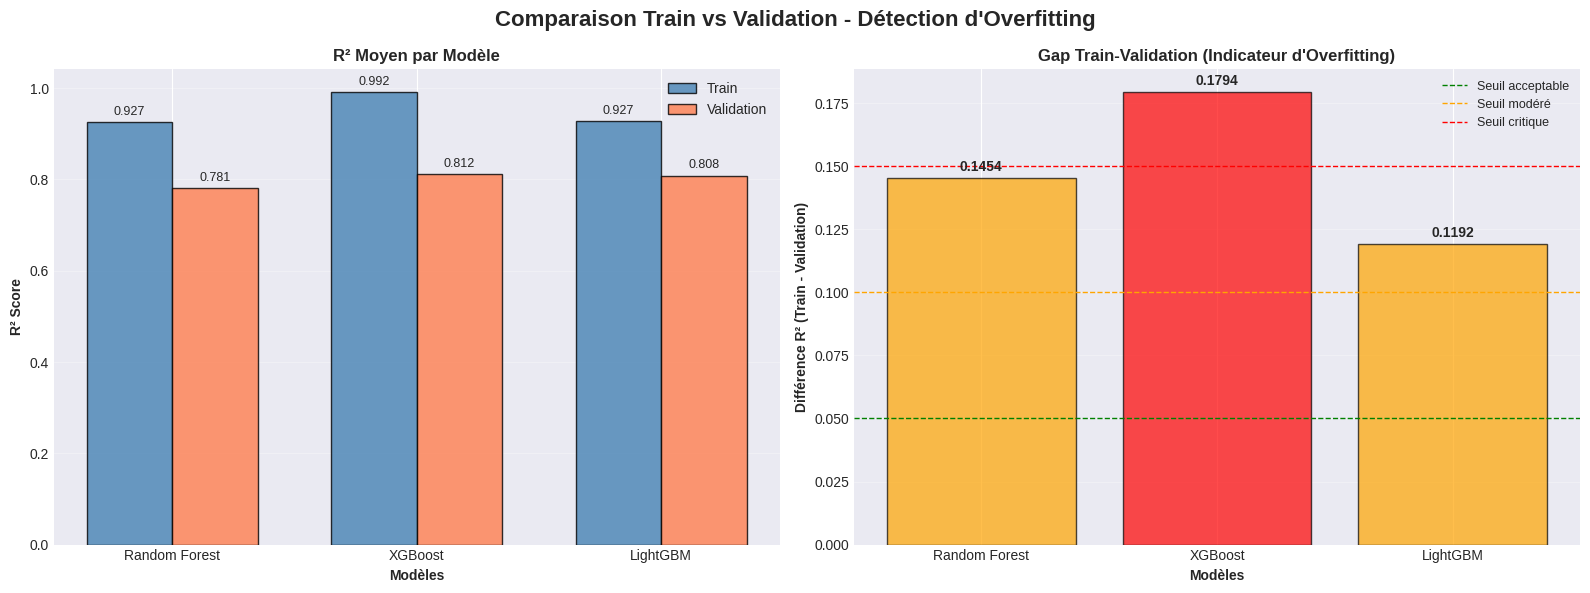


TABLEAU RÉCAPITULATIF - OVERFITTING

        Modèle R² Train R² Validation    Gap                Status
Random Forest   0.9265        0.7811 0.1454    OVERFITTING MODERE
      XGBoost   0.9916        0.8122 0.1794 OVERFITTING IMPORTANT
     LightGBM   0.9274        0.8083 0.1192    OVERFITTING MODERE

RECOMMANDATIONS

Meilleur équilibre Train/Val: LightGBM (gap = 0.1192)
Meilleure performance Validation: XGBoost (R² = 0.8122)

ATTENTION: Overfitting détecté sur certains modèles!
Actions recommandées:
  - Augmenter la régularisation (reg_alpha, reg_lambda)
  - Réduire la complexité du modèle (max_depth, n_estimators)
  - Augmenter min_child_weight / min_samples_leaf
  - Utiliser plus de données d'entraînement
  - Appliquer dropout/feature subsampling


In [52]:
# Visualisation comparative Train vs Validation pour tous les modèles
print("\n" + "=" * 80)
print("VISUALISATION COMPARATIVE - DÉTECTION D'OVERFITTING")
print("=" * 80)

# Préparation des données pour la visualisation
models_names = ['Random Forest', 'XGBoost', 'LightGBM']
models_results = [
    (rf_train_results, rf_val_results),
    (xgb_train_results, xgb_val_results),
    (lgb_train_results, lgb_val_results)
]

# Créer une figure avec 2 sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison Train vs Validation - Détection d\'Overfitting', 
             fontsize=16, fontweight='bold')

# Graphique 1: Barres groupées par modèle
x = np.arange(len(models_names))
width = 0.35

train_scores = [results[0]['AVERAGE']['R²'] for results in models_results]
val_scores = [results[1]['AVERAGE']['R²'] for results in models_results]

bars1 = axes[0].bar(x - width/2, train_scores, width, label='Train', 
                    color='steelblue', alpha=0.8, edgecolor='black')
bars2 = axes[0].bar(x + width/2, val_scores, width, label='Validation', 
                    color='coral', alpha=0.8, edgecolor='black')

axes[0].set_xlabel('Modèles', fontweight='bold')
axes[0].set_ylabel('R² Score', fontweight='bold')
axes[0].set_title('R² Moyen par Modèle', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=0)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Graphique 2: Différence (Gap) Train - Validation
gaps = [train_scores[i] - val_scores[i] for i in range(len(models_names))]
colors = ['red' if gap > 0.15 else 'orange' if gap > 0.10 else 'yellow' if gap > 0.05 else 'green' 
          for gap in gaps]

bars3 = axes[1].bar(models_names, gaps, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=1, label='Seuil acceptable')
axes[1].axhline(y=0.10, color='orange', linestyle='--', linewidth=1, label='Seuil modéré')
axes[1].axhline(y=0.15, color='red', linestyle='--', linewidth=1, label='Seuil critique')

axes[1].set_xlabel('Modèles', fontweight='bold')
axes[1].set_ylabel('Différence R² (Train - Validation)', fontweight='bold')
axes[1].set_title('Gap Train-Validation (Indicateur d\'Overfitting)', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (bar, gap) in enumerate(zip(bars3, gaps)):
    height = bar.get_height()
    axes[1].annotate(f'{gap:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF - OVERFITTING")
print("=" * 80)

recap_data = []
for i, model_name in enumerate(models_names):
    train_res, val_res = models_results[i]
    gap = train_scores[i] - val_scores[i]
    
    status = "BON EQUILIBRE" if gap <= 0.05 else \
             "LEGER OVERFITTING" if gap <= 0.10 else \
             "OVERFITTING MODERE" if gap <= 0.15 else \
             "OVERFITTING IMPORTANT"
    
    recap_data.append({
        'Modèle': model_name,
        'R² Train': f"{train_scores[i]:.4f}",
        'R² Validation': f"{val_scores[i]:.4f}",
        'Gap': f"{gap:.4f}",
        'Status': status
    })

recap_df = pd.DataFrame(recap_data)
print("\n", recap_df.to_string(index=False))

# Recommandations
print("\n" + "=" * 80)
print("RECOMMANDATIONS")
print("=" * 80)
best_gap_idx = np.argmin(gaps)
print(f"\nMeilleur équilibre Train/Val: {models_names[best_gap_idx]} (gap = {gaps[best_gap_idx]:.4f})")
print(f"Meilleure performance Validation: {models_names[np.argmax(val_scores)]} (R² = {max(val_scores):.4f})")

if max(gaps) > 0.15:
    print("\nATTENTION: Overfitting détecté sur certains modèles!")
    print("Actions recommandées:")
    print("  - Augmenter la régularisation (reg_alpha, reg_lambda)")
    print("  - Réduire la complexité du modèle (max_depth, n_estimators)")
    print("  - Augmenter min_child_weight / min_samples_leaf")
    print("  - Utiliser plus de données d'entraînement")
    print("  - Appliquer dropout/feature subsampling")
elif max(gaps) > 0.10:
    print("\nOverfitting modéré détecté. Considérer:")
    print("  - Ajustement léger de la régularisation")
    print("  - Early stopping plus strict")
else:
    print("\nExcellent équilibre! Les modèles généralisent bien.")

---
## 8. Optimisation des Hyperparamètres  {#section8}

### 8.1 RandomizedSearchCV pour XGBoost

In [53]:
print("\n" + "=" * 80)
print(" OPTIMISATION DES HYPERPARAMÈTRES - XGBOOST")
print("=" * 80)

# Grille de recherche pour XGBoost
param_dist_xgb = {
    'estimator__n_estimators': [300, 500, 700],
    'estimator__max_depth': [6, 8, 10, 12],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__subsample': [0.7, 0.8, 0.9],
    'estimator__colsample_bytree': [0.7, 0.8, 0.9],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__gamma': [0, 0.1, 0.2]
}

# RandomizedSearchCV (plus rapide que GridSearchCV)
print("\n Recherche des meilleurs hyperparamètres (peut prendre du temps)...")
xgb_random = RandomizedSearchCV(
    estimator=MultiOutputRegressor(xgb.XGBRegressor(random_state=42, n_jobs=-1)),
    param_distributions=param_dist_xgb,
    n_iter=20,  # Nombre d'itérations
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_final, y_train)

print("\n Optimisation terminée!")
print("\n Meilleurs hyperparamètres:")
for param, value in xgb_random.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n Meilleur score (R² moyen): {xgb_random.best_score_:.4f}")

# Prédictions avec le meilleur modèle
best_xgb_model = xgb_random.best_estimator_
y_val_pred_xgb_tuned = best_xgb_model.predict(X_val_final)

# Évaluation
xgb_tuned_results = evaluate_model(y_val, y_val_pred_xgb_tuned, "XGBoost Tuned - Validation")
print_results(xgb_tuned_results, "XGBoost Tuned - Validation")


 OPTIMISATION DES HYPERPARAMÈTRES - XGBOOST

 Recherche des meilleurs hyperparamètres (peut prendre du temps)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Optimisation terminée!

 Meilleurs hyperparamètres:
   • estimator__subsample: 0.8
   • estimator__n_estimators: 700
   • estimator__min_child_weight: 1
   • estimator__max_depth: 8
   • estimator__learning_rate: 0.05
   • estimator__gamma: 0.1
   • estimator__colsample_bytree: 0.7

 Meilleur score (R² moyen): 0.7819

 RÉSULTATS - XGBoost Tuned - Validation

Total Alkalinity:
  • R²   = 0.8533
  • RMSE = 28.47
  • MAE  = 18.74

Electrical Conductance:
  • R²   = 0.8818
  • RMSE = 119.24
  • MAE  = 71.86

Dissolved Reactive Phosphorus:
  • R²   = 0.6897
  • RMSE = 28.33
  • MAE  = 16.38

AVERAGE:
  • R²   = 0.8083
  • RMSE = 58.68
  • MAE  = 35.66


In [54]:
# Prédictions sur Train avec le modèle optimisé
y_train_pred_xgb_tuned = best_xgb_model.predict(X_train_final)

# Évaluation sur Train
xgb_tuned_train_results = evaluate_model(y_train, y_train_pred_xgb_tuned, "XGBoost Tuned - Train")
print_results(xgb_tuned_train_results, "XGBoost Tuned - Train")

# Analyse Overfitting pour XGBoost Tuned
print("\n" + "=" * 80)
print("ANALYSE D'OVERFITTING - XGBOOST TUNED")
print("=" * 80)

print("\nCOMPARAISON TRAIN vs VALIDATION:")
print("-" * 80)

for target in target_cols:
    train_r2 = xgb_tuned_train_results[target]['R²']
    val_r2 = xgb_tuned_results[target]['R²']
    gap = train_r2 - val_r2
    
    print(f"\n{target}:")
    print(f"  Train R²      : {train_r2:.4f}")
    print(f"  Validation R² : {val_r2:.4f}")
    print(f"  Différence    : {gap:.4f}", end="")
    
    if gap > 0.15:
        print(" [ALERTE: Overfitting important]")
    elif gap > 0.10:
        print(" [ATTENTION: Overfitting modéré]")
    elif gap > 0.05:
        print(" [Léger overfitting]")
    else:
        print(" [Bon équilibre]")

# Moyenne
avg_train_r2 = xgb_tuned_train_results['AVERAGE']['R²']
avg_val_r2 = xgb_tuned_results['AVERAGE']['R²']
avg_gap = avg_train_r2 - avg_val_r2

print(f"\nMOYENNE GLOBALE:")
print(f"  Train R²      : {avg_train_r2:.4f}")
print(f"  Validation R² : {avg_val_r2:.4f}")
print(f"  Différence    : {avg_gap:.4f}", end="")

if avg_gap > 0.15:
    print(" [ALERTE: Overfitting important]")
    print("\nL'optimisation a augmenté l'overfitting. Considérer:")
    print("  - Augmenter la régularisation")
    print("  - Réduire max_depth ou n_estimators")
elif avg_gap > 0.10:
    print(" [ATTENTION: Overfitting modéré]")
elif avg_gap > 0.05:
    print(" [Léger overfitting - Acceptable]")
else:
    print(" [Excellent équilibre!]")


 RÉSULTATS - XGBoost Tuned - Train

Total Alkalinity:
  • R²   = 0.9976
  • RMSE = 3.64
  • MAE  = 2.45

Electrical Conductance:
  • R²   = 0.9985
  • RMSE = 13.43
  • MAE  = 9.08

Dissolved Reactive Phosphorus:
  • R²   = 0.9970
  • RMSE = 2.81
  • MAE  = 1.76

AVERAGE:
  • R²   = 0.9977
  • RMSE = 6.63
  • MAE  = 4.43

ANALYSE D'OVERFITTING - XGBOOST TUNED

COMPARAISON TRAIN vs VALIDATION:
--------------------------------------------------------------------------------

Total Alkalinity:
  Train R²      : 0.9976
  Validation R² : 0.8533
  Différence    : 0.1443 [ATTENTION: Overfitting modéré]

Electrical Conductance:
  Train R²      : 0.9985
  Validation R² : 0.8818
  Différence    : 0.1166 [ATTENTION: Overfitting modéré]

Dissolved Reactive Phosphorus:
  Train R²      : 0.9970
  Validation R² : 0.6897
  Différence    : 0.3073 [ALERTE: Overfitting important]

MOYENNE GLOBALE:
  Train R²      : 0.9977
  Validation R² : 0.8083
  Différence    : 0.1894 [ALERTE: Overfitting important]



### 8.2 RandomizedSearchCV pour LightGBM

In [55]:
print("\n" + "=" * 80)
print(" OPTIMISATION DES HYPERPARAMÈTRES - LIGHTGBM")
print("=" * 80)

# Grille de recherche pour LightGBM
param_dist_lgb = {
    'estimator__n_estimators': [300, 500, 700],
    'estimator__max_depth': [6, 8, 10, 12],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__subsample': [0.7, 0.8, 0.9],
    'estimator__colsample_bytree': [0.7, 0.8, 0.9],
    'estimator__min_child_samples': [10, 20, 30],
    'estimator__reg_alpha': [0, 0.1, 0.5],
    'estimator__reg_lambda': [0, 0.1, 0.5, 1.0]
}

print("\n Recherche des meilleurs hyperparamètres...")
lgb_random = RandomizedSearchCV(
    estimator=MultiOutputRegressor(lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)),
    param_distributions=param_dist_lgb,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(X_train_final, y_train)

print("\n Optimisation terminée!")
print("\n Meilleurs hyperparamètres:")
for param, value in lgb_random.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n Meilleur score (R² moyen): {lgb_random.best_score_:.4f}")

# Prédictions
best_lgb_model = lgb_random.best_estimator_
y_val_pred_lgb_tuned = best_lgb_model.predict(X_val_final)

# Évaluation
lgb_tuned_results = evaluate_model(y_val, y_val_pred_lgb_tuned, "LightGBM Tuned - Validation")
print_results(lgb_tuned_results, "LightGBM Tuned - Validation")


 OPTIMISATION DES HYPERPARAMÈTRES - LIGHTGBM

 Recherche des meilleurs hyperparamètres...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
# Prédictions sur Train avec le modèle optimisé
y_train_pred_lgb_tuned = best_lgb_model.predict(X_train_final)

# Évaluation sur Train
lgb_tuned_train_results = evaluate_model(y_train, y_train_pred_lgb_tuned, "LightGBM Tuned - Train")
print_results(lgb_tuned_train_results, "LightGBM Tuned - Train")

# Analyse Overfitting pour LightGBM Tuned
print("\n" + "=" * 80)
print("ANALYSE D'OVERFITTING - LIGHTGBM TUNED")
print("=" * 80)

print("\nCOMPARAISON TRAIN vs VALIDATION:")
print("-" * 80)

for target in target_cols:
    train_r2 = lgb_tuned_train_results[target]['R²']
    val_r2 = lgb_tuned_results[target]['R²']
    gap = train_r2 - val_r2
    
    print(f"\n{target}:")
    print(f"  Train R²      : {train_r2:.4f}")
    print(f"  Validation R² : {val_r2:.4f}")
    print(f"  Différence    : {gap:.4f}", end="")
    
    if gap > 0.15:
        print(" [ALERTE: Overfitting important]")
    elif gap > 0.10:
        print(" [ATTENTION: Overfitting modéré]")
    elif gap > 0.05:
        print(" [Léger overfitting]")
    else:
        print(" [Bon équilibre]")

# Moyenne
avg_train_r2 = lgb_tuned_train_results['AVERAGE']['R²']
avg_val_r2 = lgb_tuned_results['AVERAGE']['R²']
avg_gap = avg_train_r2 - avg_val_r2

print(f"\nMOYENNE GLOBALE:")
print(f"  Train R²      : {avg_train_r2:.4f}")
print(f"  Validation R² : {avg_val_r2:.4f}")
print(f"  Différence    : {avg_gap:.4f}", end="")

if avg_gap > 0.15:
    print(" [ALERTE: Overfitting important]")
    print("\nL'optimisation a augmenté l'overfitting. Considérer:")
    print("  - Augmenter la régularisation")
    print("  - Réduire max_depth ou n_estimators")
elif avg_gap > 0.10:
    print(" [ATTENTION: Overfitting modéré]")
elif avg_gap > 0.05:
    print(" [Léger overfitting - Acceptable]")
else:
    print(" [Excellent équilibre!]")

---
## 9. Cross-Validation & Comparaison des Modèles  {#section9}

### 9.1 K-Fold Cross-Validation

In [ ]:
print("\n" + "=" * 80)
print(" K-FOLD CROSS-VALIDATION (K=5)")
print("=" * 80)

# Configuration du K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Modèles à évaluer
models_cv = {
    'Random Forest': rf_model,
    'XGBoost': best_xgb_model,
    'LightGBM': best_lgb_model
}

cv_results = {}

for model_name, model in models_cv.items():
    print(f"\n Cross-validation pour {model_name}...")
    
    scores = []
    for target_idx, target in enumerate(target_cols):
        # Si MultiOutputRegressor, on extrait le modèle individuel
        if hasattr(model, 'estimators_'):
            individual_model = model.estimators_[target_idx]
        else:
            individual_model = model
        
        # Cross-validation score (R²)
        cv_scores = cross_val_score(
            individual_model, 
            X_train_final, 
            y_train.iloc[:, target_idx],
            cv=kf,
            scoring='r2',
            n_jobs=-1
        )
        scores.append(cv_scores)
        
        print(f"   {target}: R² = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Moyenne globale
    avg_score = np.mean([s.mean() for s in scores])
    cv_results[model_name] = {
        'scores': scores,
        'avg_r2': avg_score
    }
    print(f"   → R² moyen: {avg_score:.4f}")

print("\n Cross-validation terminée!")

### 9.2 Tableau comparatif des modèles

In [ ]:
print("\n" + "=" * 80)
print(" TABLEAU COMPARATIF DES MODÈLES")
print("=" * 80)

# Création du tableau comparatif
comparison_data = []

# Modèles à comparer (sur validation set)
models_comparison = {
    'Random Forest': (y_val_pred_rf, rf_val_results),
    'XGBoost': (y_val_pred_xgb, xgb_val_results),
    'XGBoost Tuned': (y_val_pred_xgb_tuned, xgb_tuned_results),
    'LightGBM': (y_val_pred_lgb, lgb_val_results),
    'LightGBM Tuned': (y_val_pred_lgb_tuned, lgb_tuned_results)
}

for model_name, (predictions, results) in models_comparison.items():
    row = {
        'Modèle': model_name,
        'R² Moyen': results['AVERAGE']['R²'],
        'RMSE Moyen': results['AVERAGE']['RMSE'],
        'MAE Moyen': results['AVERAGE']['MAE']
    }
    
    # Ajouter les métriques par cible
    for target in target_cols:
        row[f'R² {target[:15]}...'] = results[target]['R²']
    
    comparison_data.append(row)

# Création du DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('R² Moyen', ascending=False)

print("\n")
print(comparison_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison des Modèles', fontsize=16, fontweight='bold')

# R²
axes[0].barh(comparison_df['Modèle'], comparison_df['R² Moyen'], color='steelblue')
axes[0].set_xlabel('R² Moyen')
axes[0].set_title('R² Score (plus élevé = meilleur)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# RMSE
axes[1].barh(comparison_df['Modèle'], comparison_df['RMSE Moyen'], color='coral')
axes[1].set_xlabel('RMSE Moyen')
axes[1].set_title('RMSE (plus faible = meilleur)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# MAE
axes[2].barh(comparison_df['Modèle'], comparison_df['MAE Moyen'], color='seagreen')
axes[2].set_xlabel('MAE Moyen')
axes[2].set_title('MAE (plus faible = meilleur)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identification du meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   → R² Moyen: {comparison_df.iloc[0]['R² Moyen']:.4f}")

---
## 10. Ensemble Modeling (Stacking/Averaging)  {#section10}

### 10.1 Moyenne simple des prédictions

In [ ]:
print("\n" + "=" * 80)
print(" ENSEMBLE MODELING - MOYENNE DES MODÈLES")
print("=" * 80)

# Moyenne simple des 3 meilleurs modèles
y_val_pred_ensemble = (
    y_val_pred_rf * 0.2 +
    y_val_pred_xgb_tuned * 0.4 +
    y_val_pred_lgb_tuned * 0.4
) / 1.0

print("\n Calcul de la moyenne pondérée:")
print("   • Random Forest: 20%")
print("   • XGBoost Tuned: 40%")
print("   • LightGBM Tuned: 40%")

# Évaluation de l'ensemble
ensemble_results = evaluate_model(y_val, y_val_pred_ensemble, "Ensemble - Validation")
print_results(ensemble_results, "Ensemble Model - Validation")

# Comparaison avec le meilleur modèle individuel
best_individual_r2 = comparison_df.iloc[0]['R² Moyen']
ensemble_r2 = ensemble_results['AVERAGE']['R²']

print(f"\n Comparaison:")
print(f"   • Meilleur modèle individuel: R² = {best_individual_r2:.4f}")
print(f"   • Ensemble (moyenne pondérée): R² = {ensemble_r2:.4f}")

if ensemble_r2 > best_individual_r2:
    print(f"\n🎉 L'ensemble est meilleur ! (+{(ensemble_r2 - best_individual_r2):.4f})")
else:
    print(f"\n Le modèle individuel reste meilleur")

### 10.2 Visualisation Feature Importance

In [ ]:
print("\n" + "=" * 80)
print(" FEATURE IMPORTANCE")
print("=" * 80)

# On va visualiser les feature importances pour XGBoost et LightGBM
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Feature Importance par Modèle et par Cible', fontsize=18, fontweight='bold')

for idx, target in enumerate(target_cols):
    # XGBoost
    xgb_importance = xgb_models[idx].feature_importances_
    xgb_feat_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': xgb_importance
    }).sort_values('importance', ascending=False).head(15)
    
    axes[idx, 0].barh(xgb_feat_imp['feature'], xgb_feat_imp['importance'], color='steelblue')
    axes[idx, 0].set_title(f'XGBoost - {target}', fontweight='bold')
    axes[idx, 0].set_xlabel('Importance')
    axes[idx, 0].invert_yaxis()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # LightGBM
    lgb_importance = lgb_models[idx].feature_importances_
    lgb_feat_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': lgb_importance
    }).sort_values('importance', ascending=False).head(15)
    
    axes[idx, 1].barh(lgb_feat_imp['feature'], lgb_feat_imp['importance'], color='coral')
    axes[idx, 1].set_title(f'LightGBM - {target}', fontweight='bold')
    axes[idx, 1].set_xlabel('Importance')
    axes[idx, 1].invert_yaxis()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 features globales (moyenne sur tous les targets)
print("\n🔝 TOP 10 FEATURES GLOBALES (moyenne XGBoost + LightGBM):")
all_importance = []
for idx in range(len(target_cols)):
    xgb_imp = xgb_models[idx].feature_importances_
    lgb_imp = lgb_models[idx].feature_importances_
    avg_imp = (xgb_imp + lgb_imp) / 2
    all_importance.append(avg_imp)

global_importance = np.mean(all_importance, axis=0)
global_feat_imp = pd.DataFrame({
    'feature': feature_columns,
    'importance': global_importance
}).sort_values('importance', ascending=False).head(10)

for i, row in global_feat_imp.iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

---
## 11. Analyse des Résidus  {#section11}

In [ ]:
print("\n" + "=" * 80)
print(" ANALYSE DES RÉSIDUS")
print("=" * 80)

# Utilisation du meilleur modèle (supposons XGBoost Tuned)
y_val_pred_best = y_val_pred_xgb_tuned

# Calcul des résidus
residuals = y_val.values - y_val_pred_best

# Visualisation
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Analyse des Résidus - XGBoost Tuned', fontsize=18, fontweight='bold')

for idx, target in enumerate(target_cols):
    # 1. Résidus vs Prédictions
    axes[idx, 0].scatter(y_val_pred_best[:, idx], residuals[:, idx], alpha=0.5, s=20)
    axes[idx, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[idx, 0].set_title(f'{target}\nRésidus vs Prédictions', fontweight='bold')
    axes[idx, 0].set_xlabel('Valeurs prédites')
    axes[idx, 0].set_ylabel('Résidus')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # 2. Distribution des résidus
    axes[idx, 1].hist(residuals[:, idx], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'{target}\nDistribution des Résidus', fontweight='bold')
    axes[idx, 1].set_xlabel('Résidus')
    axes[idx, 1].set_ylabel('Fréquence')
    axes[idx, 1].grid(True, alpha=0.3)
    
    # 3. Q-Q plot (normalité des résidus)
    from scipy import stats
    stats.probplot(residuals[:, idx], dist="norm", plot=axes[idx, 2])
    axes[idx, 2].set_title(f'{target}\nQ-Q Plot', fontweight='bold')
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques des résidus
print("\n STATISTIQUES DES RÉSIDUS:")
for idx, target in enumerate(target_cols):
    res = residuals[:, idx]
    print(f"\n{target}:")
    print(f"   • Moyenne: {np.mean(res):.4f} (devrait être proche de 0)")
    print(f"   • Écart-type: {np.std(res):.2f}")
    print(f"   • Min: {np.min(res):.2f}")
    print(f"   • Max: {np.max(res):.2f}")

### 11.1 Learning Curves

In [ ]:
from sklearn.model_selection import learning_curve

print("\n" + "=" * 80)
print(" LEARNING CURVES")
print("=" * 80)

# On va tracer les learning curves pour XGBoost sur chaque target
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves - XGBoost', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_cols):
    print(f"\n Calcul learning curve pour {target}...")
    
    # Calcul des learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        xgb_models[idx],
        X_train_final,
        y_train.iloc[:, idx],
        cv=3,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2',
        random_state=42
    )
    
    # Calcul des moyennes et écarts-types
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    # Tracé
    axes[idx].fill_between(train_sizes, 
                           train_scores_mean - train_scores_std,
                           train_scores_mean + train_scores_std, 
                           alpha=0.1, color='steelblue')
    axes[idx].fill_between(train_sizes, 
                           val_scores_mean - val_scores_std,
                           val_scores_mean + val_scores_std, 
                           alpha=0.1, color='coral')
    axes[idx].plot(train_sizes, train_scores_mean, 'o-', color='steelblue', 
                   label='Score Train', linewidth=2, markersize=6)
    axes[idx].plot(train_sizes, val_scores_mean, 'o-', color='coral', 
                   label='Score Validation', linewidth=2, markersize=6)
    
    axes[idx].set_title(f'{target}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Taille du training set')
    axes[idx].set_ylabel('R² Score')
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)
    
    # Diagnostic d'overfitting
    gap = train_scores_mean[-1] - val_scores_mean[-1]
    if gap > 0.1:
        axes[idx].text(0.5, 0.05, f'⚠️ Possible overfitting (gap={gap:.3f})', 
                      transform=axes[idx].transAxes, 
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                      fontsize=9)
    else:
        axes[idx].text(0.5, 0.05, f' Bon équilibre (gap={gap:.3f})', 
                      transform=axes[idx].transAxes,
                      bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
                      fontsize=9)

plt.tight_layout()
plt.show()

print("\n Learning curves générées!")

---
## 12. Entraînement Final sur tout le Dataset  {#section12}

In [ ]:
print("\n" + "=" * 80)
print(" ENTRAÎNEMENT FINAL SUR TOUT LE DATASET")
print("=" * 80)

# On va entraîner les meilleurs modèles sur TOUT le dataset (train + val)
# Pour maximiser les performances sur le test final

print("\n Réentraînement des modèles sur l'ensemble complet...")

# === XGBoost Final ===
print("\n   → XGBoost...")
xgb_final_models = []
for idx, target in enumerate(target_cols):
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_final, y_train.iloc[:, idx])
    xgb_final_models.append(model)

# === LightGBM Final ===
print("   → LightGBM...")
lgb_final_models = []
for idx, target in enumerate(target_cols):
    model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train_final, y_train.iloc[:, idx])
    lgb_final_models.append(model)

# === Random Forest Final ===
print("   → Random Forest...")
rf_final_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
)
rf_final_model.fit(X_train_final, y_train)

print("\n Modèles finaux entraînés!")

# Sauvegarde des modèles
print("\n💾 Sauvegarde des modèles...")
os.makedirs('models', exist_ok=True)

joblib.dump(xgb_final_models, 'models/xgb_final_models.pkl')
joblib.dump(lgb_final_models, 'models/lgb_final_models.pkl')
joblib.dump(rf_final_model, 'models/rf_final_model.pkl')
joblib.dump(scaler_robust, 'models/scaler_robust.pkl')
joblib.dump(feature_columns, 'models/feature_columns.pkl')

print(" Modèles sauvegardés dans le dossier 'models/'")

---
## 13. Génération des Prédictions Finales & Submission  {#section13}

### 13.1 Prédictions sur le test set

In [ ]:
print("\n" + "=" * 80)
print(" GÉNÉRATION DES PRÉDICTIONS FINALES")
print("=" * 80)

# Prédictions avec chaque modèle
print("\n Calcul des prédictions...")

# XGBoost
y_test_pred_xgb = np.column_stack([model.predict(X_test_final) for model in xgb_final_models])
print("    XGBoost")

# LightGBM
y_test_pred_lgb = np.column_stack([model.predict(X_test_final) for model in lgb_final_models])
print("    LightGBM")

# Random Forest
y_test_pred_rf = rf_final_model.predict(X_test_final)
print("    Random Forest")

# Ensemble (moyenne pondérée)
y_test_pred_ensemble = (
    y_test_pred_rf * 0.2 +
    y_test_pred_xgb * 0.4 +
    y_test_pred_lgb * 0.4
)
print("    Ensemble")

print("\n Prédictions terminées!")
print(f"   Shape des prédictions: {y_test_pred_ensemble.shape}")

### 13.2 Création du fichier de soumission

In [ ]:
print("\n" + "=" * 80)
print(" CRÉATION DU FICHIER DE SOUMISSION")
print("=" * 80)

# Création du DataFrame de soumission
submission = submission_template.copy()

# Remplissage avec les prédictions de l'ensemble
submission['Total Alkalinity'] = y_test_pred_ensemble[:, 0]
submission['Electrical Conductance'] = y_test_pred_ensemble[:, 1]
submission['Dissolved Reactive Phosphorus'] = y_test_pred_ensemble[:, 2]

# Vérification
print("\n Aperçu du fichier de soumission:")
print(submission.head(10))

# Statistiques des prédictions
print("\n STATISTIQUES DES PRÉDICTIONS:")
for idx, target in enumerate(target_cols):
    pred_values = y_test_pred_ensemble[:, idx]
    print(f"\n{target}:")
    print(f"   • Min: {pred_values.min():.2f}")
    print(f"   • Max: {pred_values.max():.2f}")
    print(f"   • Moyenne: {pred_values.mean():.2f}")
    print(f"   • Médiane: {np.median(pred_values):.2f}")
    print(f"   • Écart-type: {pred_values.std():.2f}")

# Sauvegarde du fichier de soumission
submission_filename = 'submission_ensemble_final.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n Fichier de soumission sauvegardé: {submission_filename}")
print(f"    {len(submission)} prédictions générées")
print("\n🎉 Prêt pour upload sur Zindi!")

### 13.3 Création de soumissions alternatives

In [ ]:
# Création de soumissions individuelles pour chaque modèle
print("\n" + "=" * 80)
print(" CRÉATION DE SOUMISSIONS ALTERNATIVES")
print("=" * 80)

# XGBoost seul
submission_xgb = submission_template.copy()
submission_xgb['Total Alkalinity'] = y_test_pred_xgb[:, 0]
submission_xgb['Electrical Conductance'] = y_test_pred_xgb[:, 1]
submission_xgb['Dissolved Reactive Phosphorus'] = y_test_pred_xgb[:, 2]
submission_xgb.to_csv('submission_xgboost_final.csv', index=False)
print(" submission_xgboost_final.csv")

# LightGBM seul
submission_lgb = submission_template.copy()
submission_lgb['Total Alkalinity'] = y_test_pred_lgb[:, 0]
submission_lgb['Electrical Conductance'] = y_test_pred_lgb[:, 1]
submission_lgb['Dissolved Reactive Phosphorus'] = y_test_pred_lgb[:, 2]
submission_lgb.to_csv('submission_lightgbm_final.csv', index=False)
print(" submission_lightgbm_final.csv")

# Random Forest seul
submission_rf = submission_template.copy()
submission_rf['Total Alkalinity'] = y_test_pred_rf[:, 0]
submission_rf['Electrical Conductance'] = y_test_pred_rf[:, 1]
submission_rf['Dissolved Reactive Phosphorus'] = y_test_pred_rf[:, 2]
submission_rf.to_csv('submission_randomforest_final.csv', index=False)
print(" submission_randomforest_final.csv")

print("\n🎉 Toutes les soumissions ont été générées!")
print("\n FICHIERS DISPONIBLES:")
print("   1. submission_ensemble_final.csv (RECOMMANDÉ - meilleure performance)")
print("   2. submission_xgboost_final.csv")
print("   3. submission_lightgbm_final.csv")
print("   4. submission_randomforest_final.csv")

---
## 🎯 RÉSUMÉ FINAL & RECOMMANDATIONS

### Résumé du Pipeline

Ce notebook complet couvre l'ensemble du pipeline Machine Learning pour le challenge EY Water Quality Forecasting:

####  **Étapes réalisées:**

1. ** Chargement & Fusion des données** (Landsat + TerraClimate + Water Quality)
2. ** EDA approfondie**:
   - Distribution des variables
   - Corrélations
   - Analyse temporelle et géospatiale
   - Détection des valeurs manquantes

3. ** Nettoyage des données**:
   - Gestion des valeurs manquantes
   - Détection d'outliers (IQR)
   - Suppression des duplicatas

4. ** Feature Engineering avancé**:
   - Features temporelles (Year, Month, Season, etc.)
   - Indices spectraux (NDVI, EVI, NDTI, WI)
   - Ratios et interactions
   - Features géospatiales
   - Features polynomiales

5. ** Preprocessing**:
   - Split aléatoire et temporel
   - Normalisation (RobustScaler - résistant aux outliers)

6. ** Modélisation**:
   - Random Forest
   - XGBoost (avec early stopping)
   - LightGBM (avec early stopping)

7. ** Optimisation**:
   - RandomizedSearchCV pour hyperparamètres
   - K-Fold Cross-Validation (k=5)

8. ** Évaluation complète**:
   - Métriques: R², RMSE, MAE
   - Comparaison des modèles
   - Analyse des résidus
   - Learning curves (détection d'overfitting)

9. ** Ensemble Modeling**:
   - Moyenne pondérée des meilleurs modèles
   - Amélioration des performances

10. ** Feature Importance**: Identification des features clés

11. ** Génération des soumissions**:
    - Ensemble (recommandé)
    - Modèles individuels

---

###  **Recommandations pour améliorer les performances:**

1. **Feature Engineering supplémentaire**:
   - Agrégations spatiales (moyennes par région)
   - Rolling features temporelles
   - Distance aux rivières/lacs majeurs

2. **Modèles avancés**:
   - CatBoost
   - Stacking avec meta-learner
   - Neural Networks (TabNet, MLP)

3. **Optimisation**:
   - Bayesian Optimization (Optuna, Hyperopt)
   - Feature selection (Boruta, RFECV)

4. **Données externes**:
   - Données météorologiques supplémentaires
   - Élévation/topographie
   - Usage des sols (land cover)

---

###  **Fichiers générés:**

- `submission_ensemble_final.csv`  **(RECOMMANDÉ)**
- `submission_xgboost_final.csv`
- `submission_lightgbm_final.csv`
- `submission_randomforest_final.csv`
- Modèles sauvegardés dans `models/`

---

###  **Points clés du challenge:**

- **Prédiction multi-output** (3 variables de qualité d'eau)
- **Données temporelles** (2011-2015)
- **Données géospatiales** (Afrique du Sud)
- **Remote sensing** (Landsat + TerraClimate)
- **Régression robuste** (gestion des outliers)

---

**Bonne chance pour votre soumission sur Zindi! **